# Interpolation and Extrapolation

We will often run into a situation where we need to interpolate or extrapolate.  

When might you want to interpolate?

One situation is with data, where we have a set of points but want to evaluate values inbetween.  The other common situation is when evaluating a function takes a long time.  For instance, in the past problems the time it takes to calculate an electric or magnetic field is significant.  We needed to wait several minutes to plot the field, for example.  

We are going to look at several interpolation routines, in a way very similar to what we did for derivatives or for integrals.  

First we define two test functions, that we will use to generate a table of values, and then interpolate based on the table.  One will be relatively smooth:
$$f(x)=\rm{sinc } x=\frac{\sin x}{x}$$

A second will be a "triangle wave", peaked at x=0.5.

We start by defining and plotting the functions.


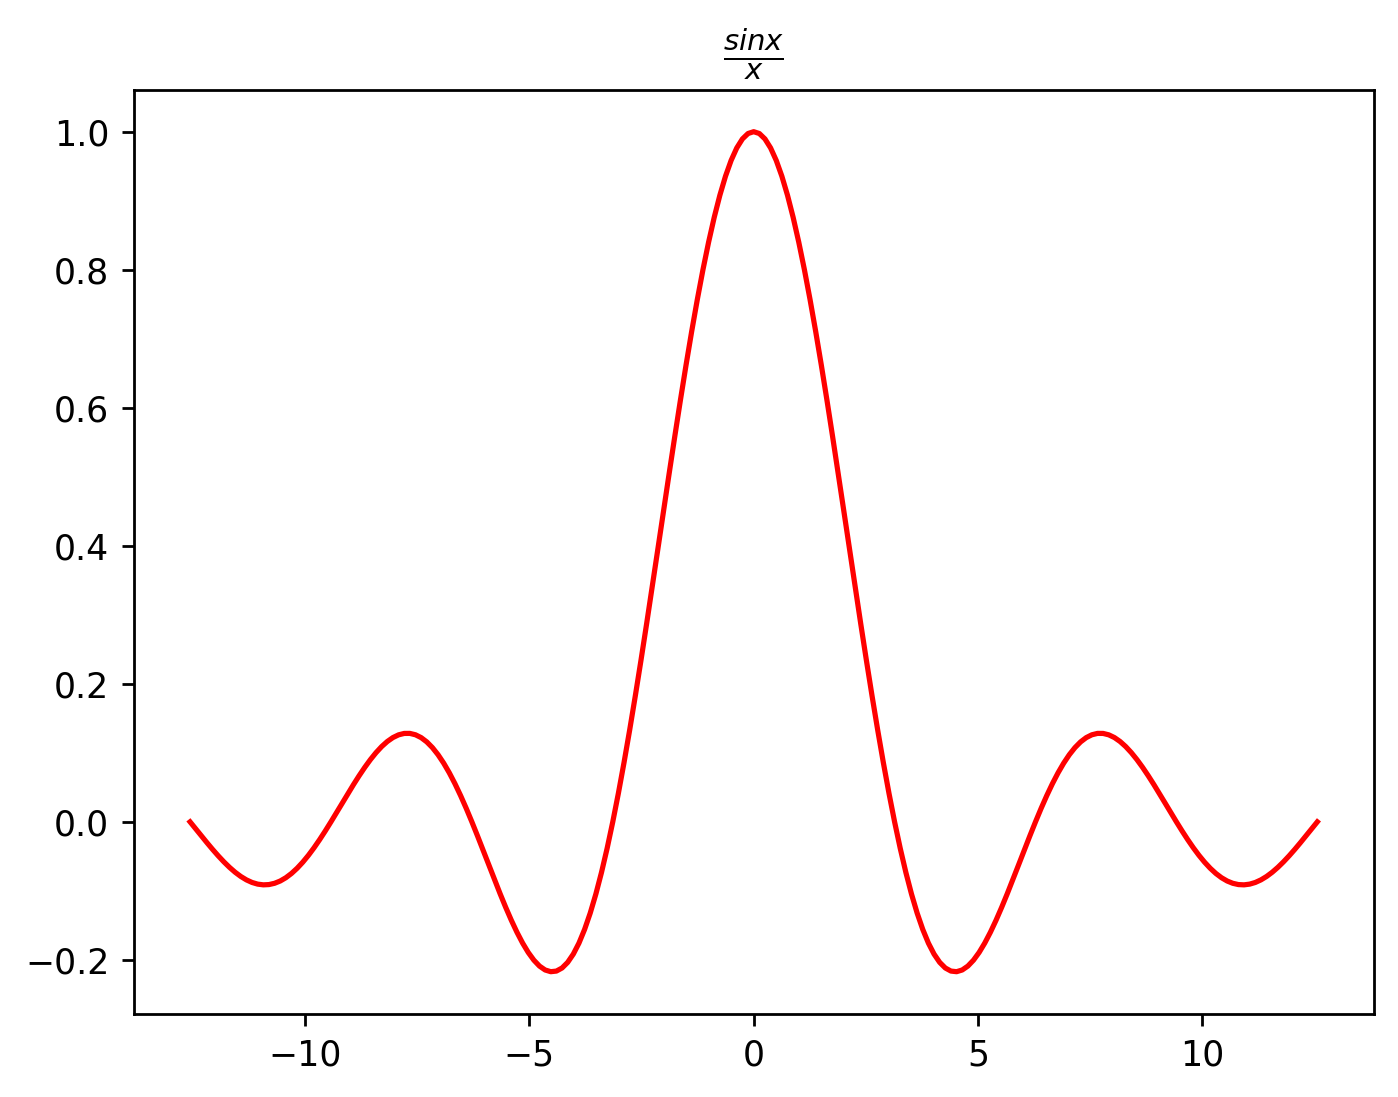

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rc('figure',dpi=250)

def sinc(x):
    return np.where(x==0,np.ones_like(x),np.sin(x)/x)

def triangle(x):
    return np.where(x<.5,x,1-x)

x=np.linspace(-4*np.pi,4*np.pi,201)
#x=np.linspace(-4,4,201)

plt.title(r'$\frac{sin x}{x}$')
plt.plot(x,sinc(x),color='red'),
plt.show()

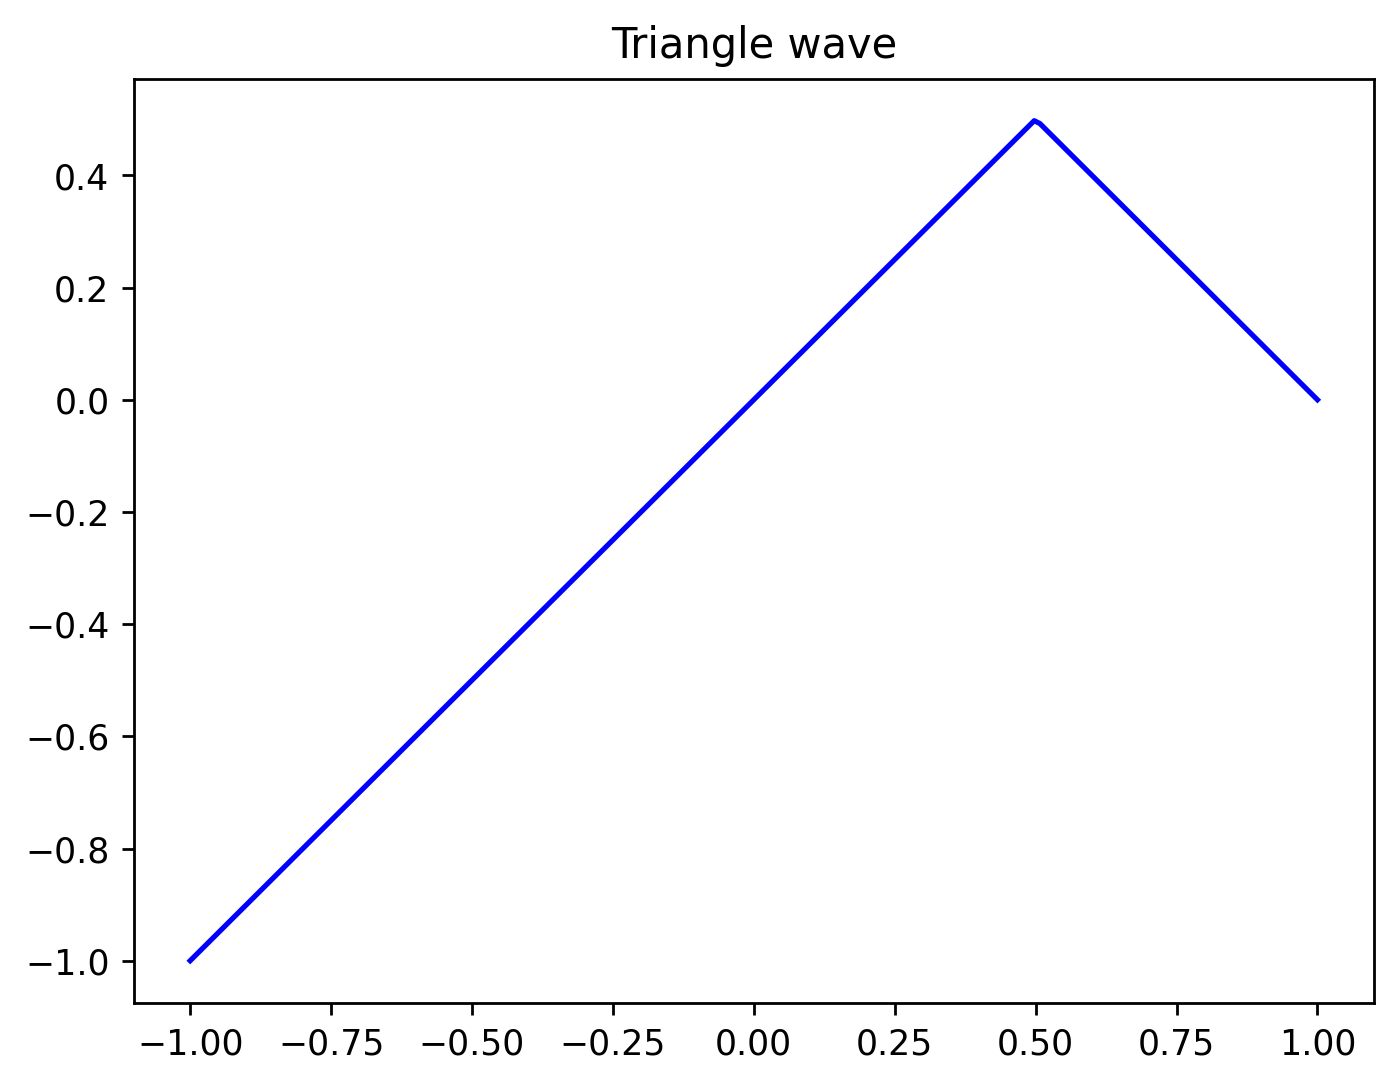

In [3]:
xt=np.linspace(-1,1,200)
plt.plot(xt,triangle(xt),color='blue')
plt.title("Triangle wave")
plt.show()

# Linear Interpolation
Easiest algorithm is simply to put two neighboring points on a straight line:

$$y(x)=\frac{y_{i+1}-y_i}{x_{i+1}-x_i}(x-x_i)+y_i,$$
where i+1 and i refer to the points on either side of x.

We could easily code this, but it is already done in numpy, with np.interp.

/tmp/ipykernel_2152/667808697.py:7: RuntimeWarning: invalid value encountered in divide
  return np.where(x==0,np.ones_like(x),np.sin(x)/x)


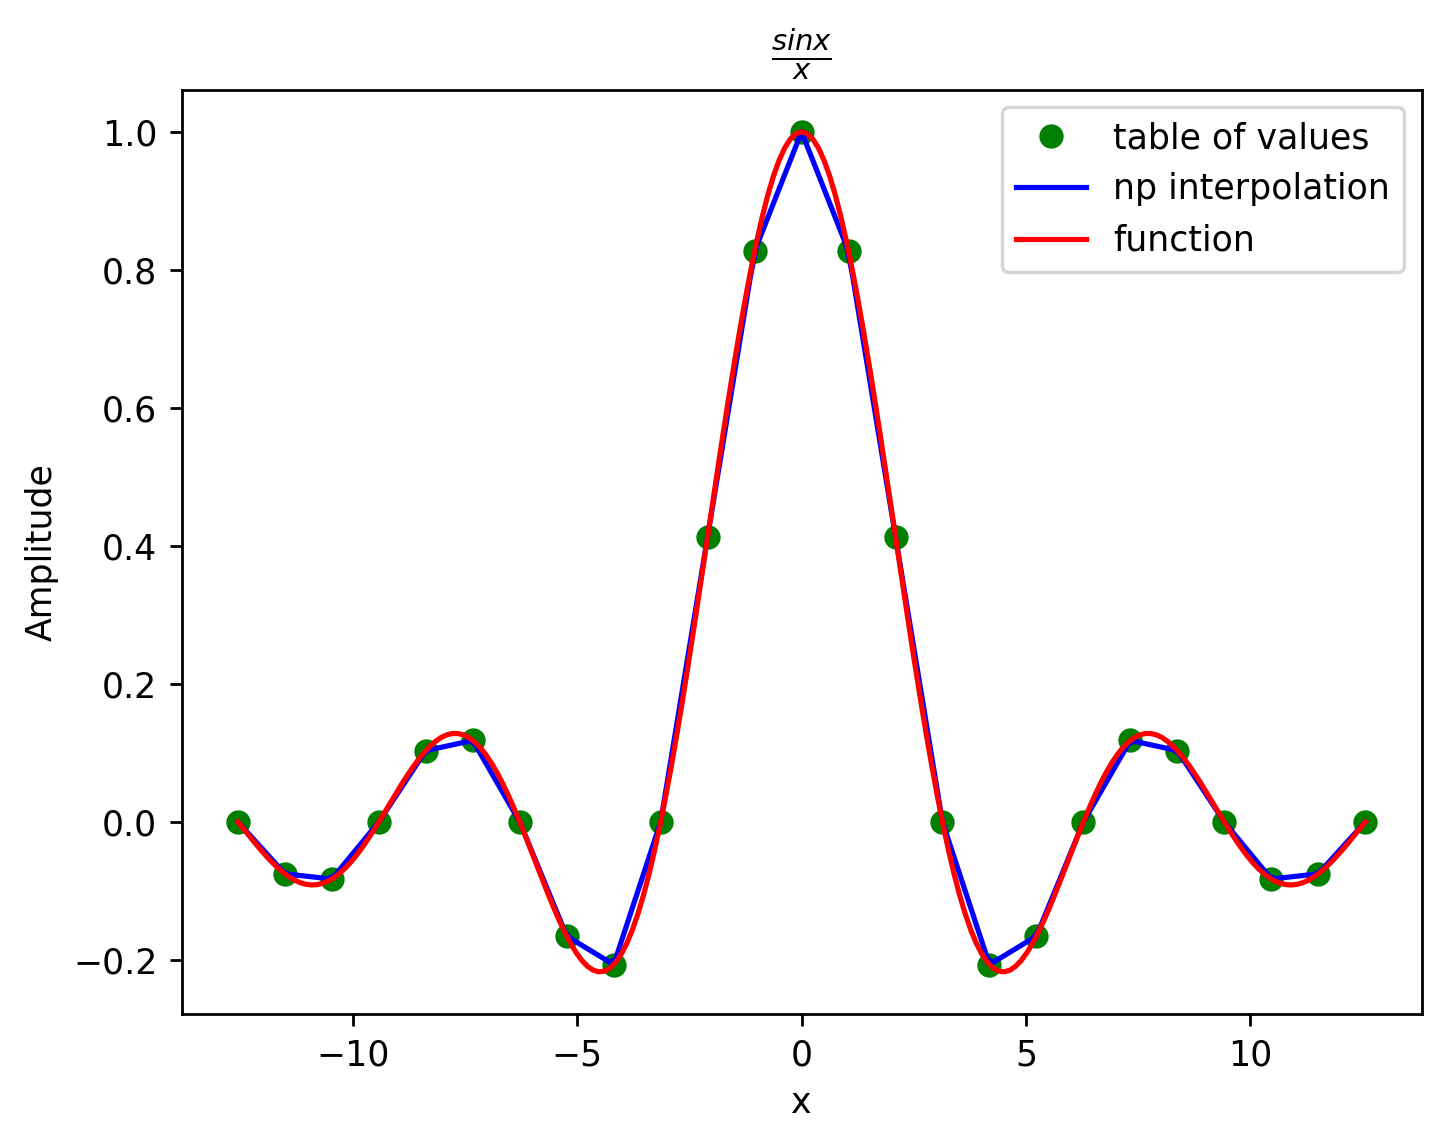

[-12.56637061 -11.51917306 -10.47197551  -9.42477796  -8.37758041
  -7.33038286  -6.28318531  -5.23598776  -4.1887902   -3.14159265
  -2.0943951   -1.04719755   0.           1.04719755   2.0943951
   3.14159265   4.1887902    5.23598776   6.28318531   7.33038286
   8.37758041   9.42477796  10.47197551  11.51917306  12.56637061] [-3.89817183e-17 -7.51812130e-02 -8.26993343e-02  3.89817183e-17
  1.03374168e-01  1.18141906e-01 -3.89817183e-17 -1.65398669e-01
 -2.06748336e-01  3.89817183e-17  4.13496672e-01  8.26993343e-01
  1.00000000e+00  8.26993343e-01  4.13496672e-01  6.04413662e-16
 -2.06748336e-01 -1.65398669e-01 -3.89817183e-17  1.18141906e-01
  1.03374168e-01  3.89817183e-17 -8.26993343e-02 -7.51812130e-02
 -3.89817183e-17]


In [4]:
tablex=np.linspace(-4*np.pi,4*np.pi,25)
tabley=sinc(tablex)
linear=np.interp(x,tablex,tabley)
plt.plot(tablex,tabley,'o',color='green',label='table of values')
plt.plot(x,linear,color='blue',label='np interpolation')
plt.plot(x,sinc(x),color='red',label='function')
plt.title(r'$\frac{sin x}{x}$')
plt.xlabel("x")
plt.ylabel("Amplitude")
plt.legend()
plt.show()
print(tablex,tabley)

We show the differences a little more cleanly by subtracting:

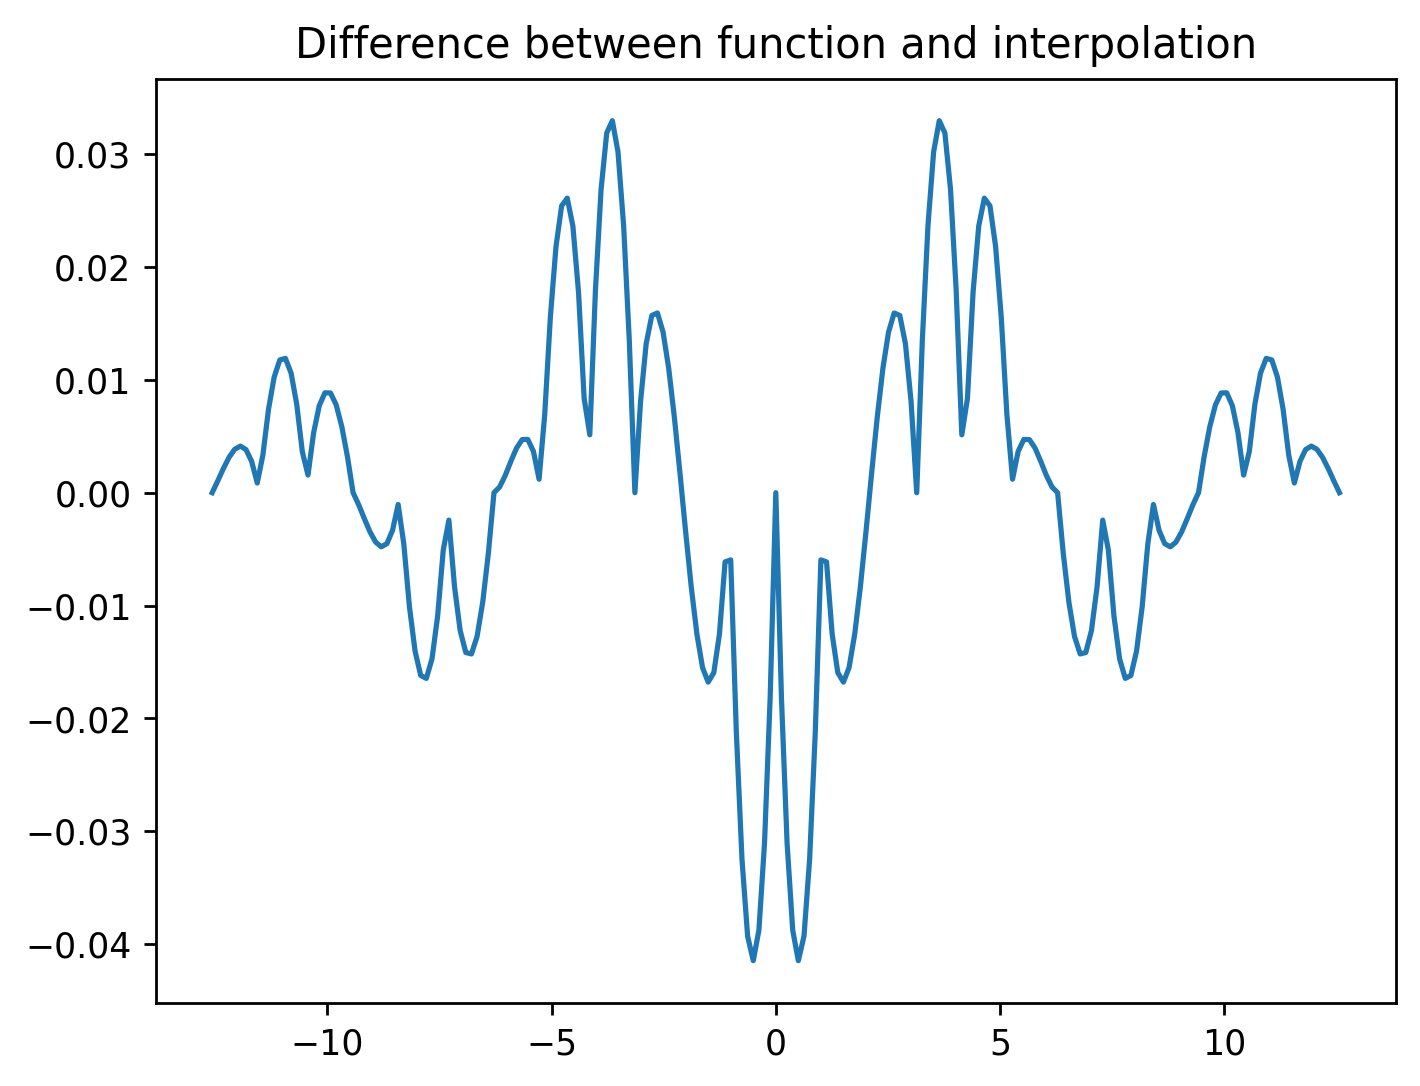

In [18]:
plt.plot(x,linear-sinc(x))
plt.title("Difference between function and interpolation")
plt.show()

We can do better by having more points.

However, an issue we have is that the interpolating function isn't smooth- but has a discontinuous derivative.  

In [19]:
def derivative(f,x):
    xp=x+5e-6
    xm=x-5e-6
    return (f(xp)-f(xm))/(xp-xm)

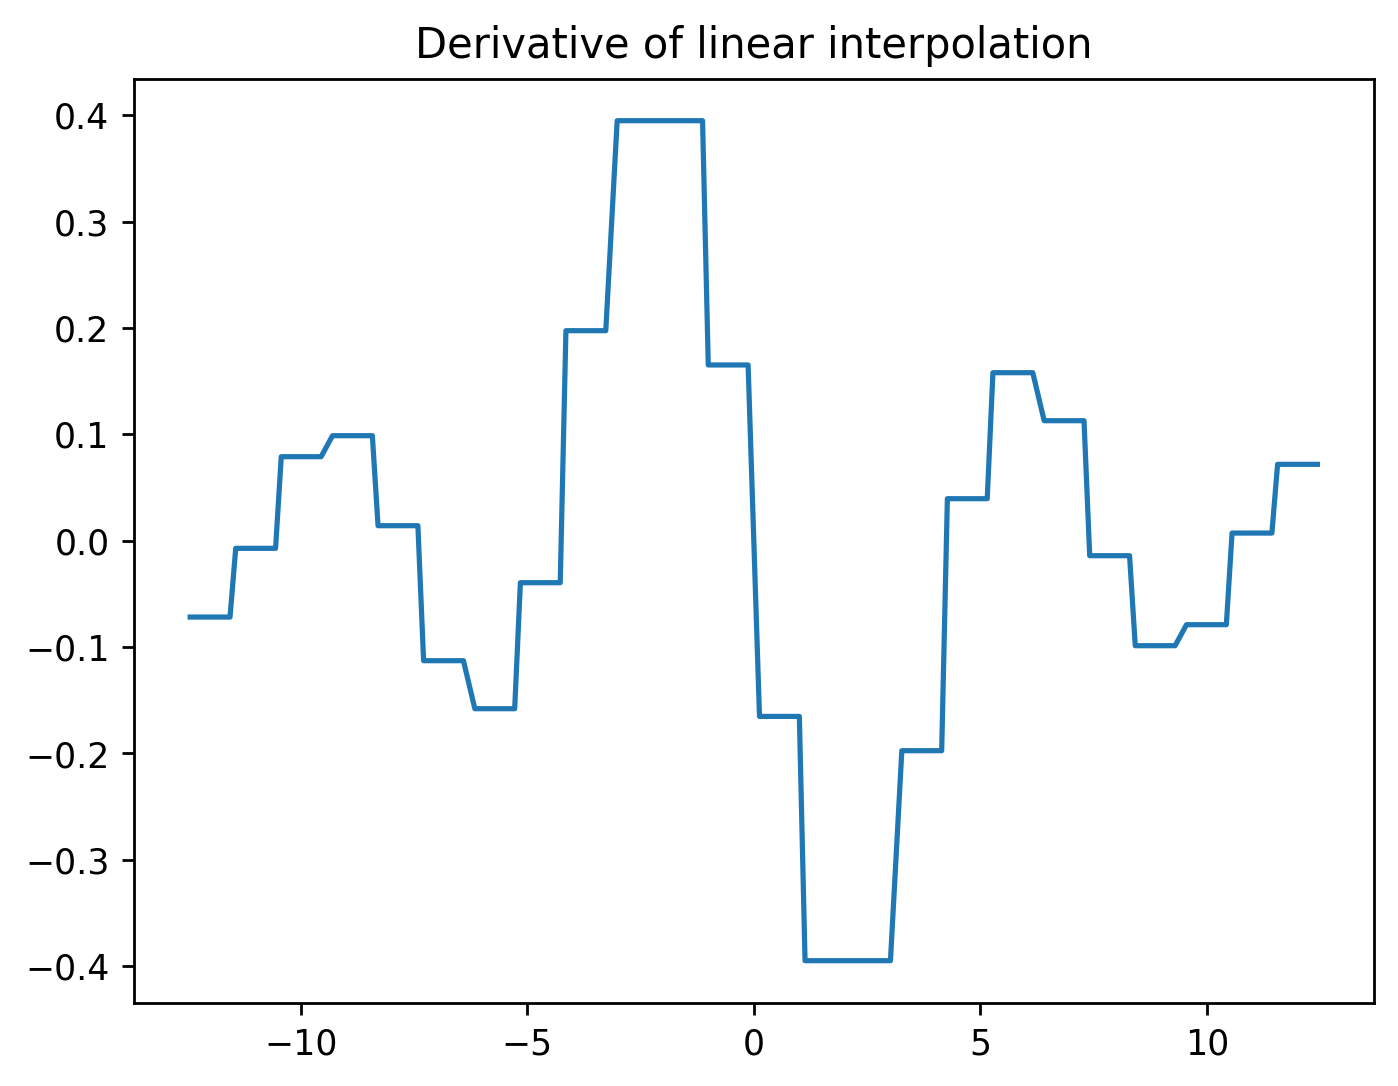

In [20]:
plt.plot(x[1:-1],derivative(lambda xx:np.interp(xx,tablex,tabley),x[1:-1]))
plt.title("Derivative of linear interpolation")
plt.show()

If we need smoothness, we go to spline interpolation.  

What this does is to impose the condition:  the second derivative should also be continuous.  We add an unknown second derivative at each data point, and linearly interpolate those second derivatives between data points. This ends up requiring cubic polynomials between data points.

The positive outcome is that the interpolated function is continuous.  This works very nicely in many applications.  The second derivative isn't smooth, and the interpolation value at a particular place actually depends on values of the function that are not close.  One can increase smoothness with higher order polynomials; and precision by increasing the number of data points.  

Try it out with k=3 (cubic spline) in make_interp_spline

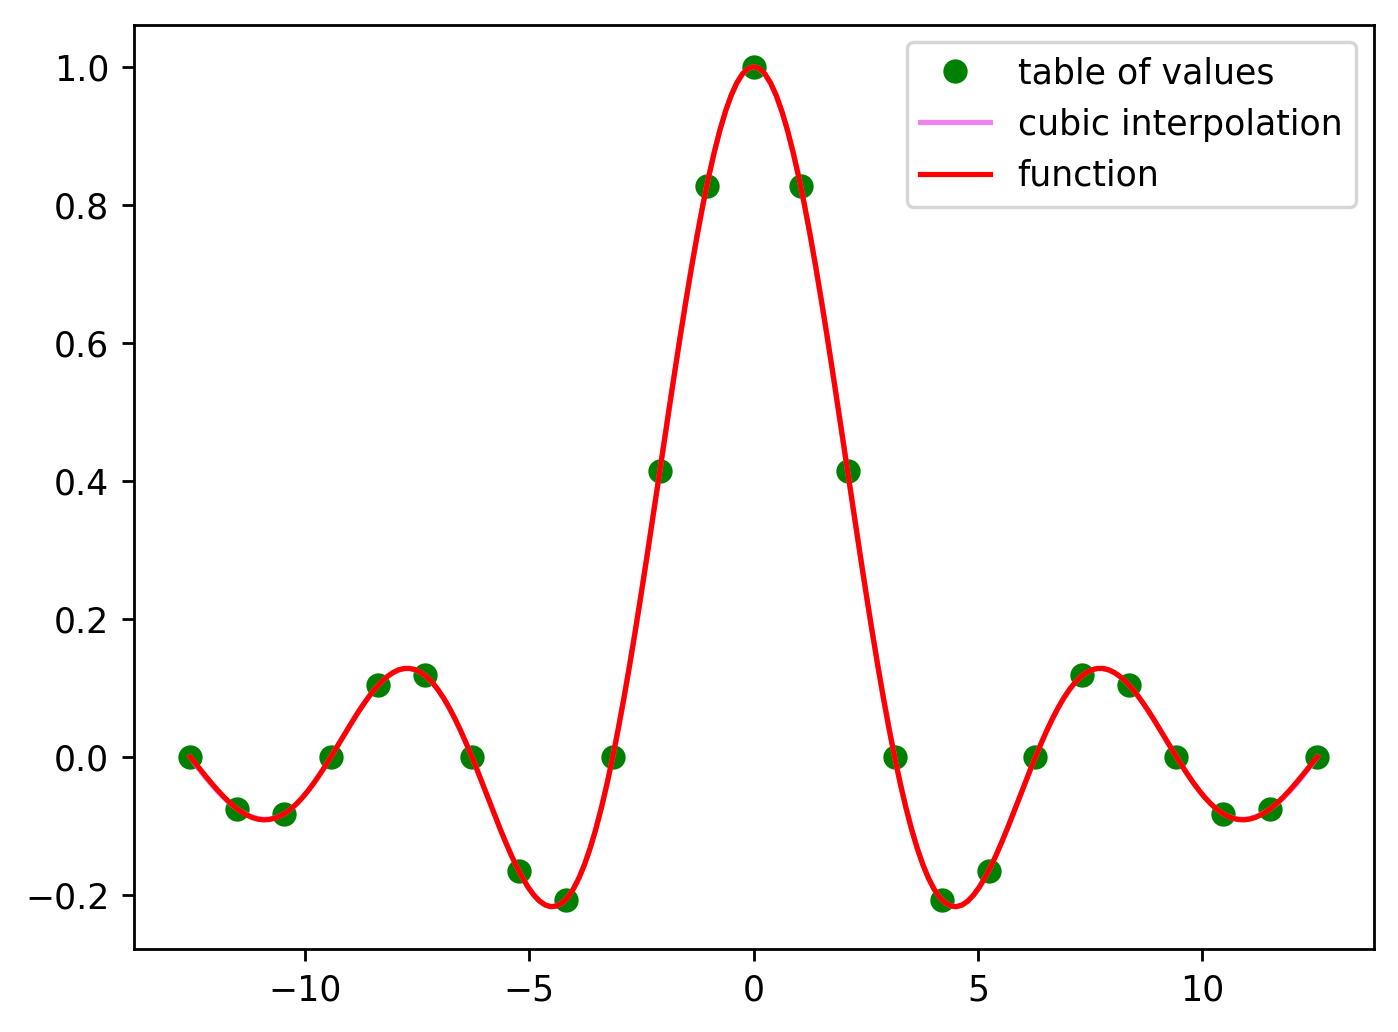

In [21]:
from scipy.interpolate import make_interp_spline
spline=make_interp_spline(tablex,tabley,k=3)

plt.plot(tablex,tabley,'o',color='green',label='table of values')
plt.plot(x,spline(x),color='violet',label='cubic interpolation')
plt.plot(x,sinc(x),color='red',label='function')
plt.legend()
plt.show()

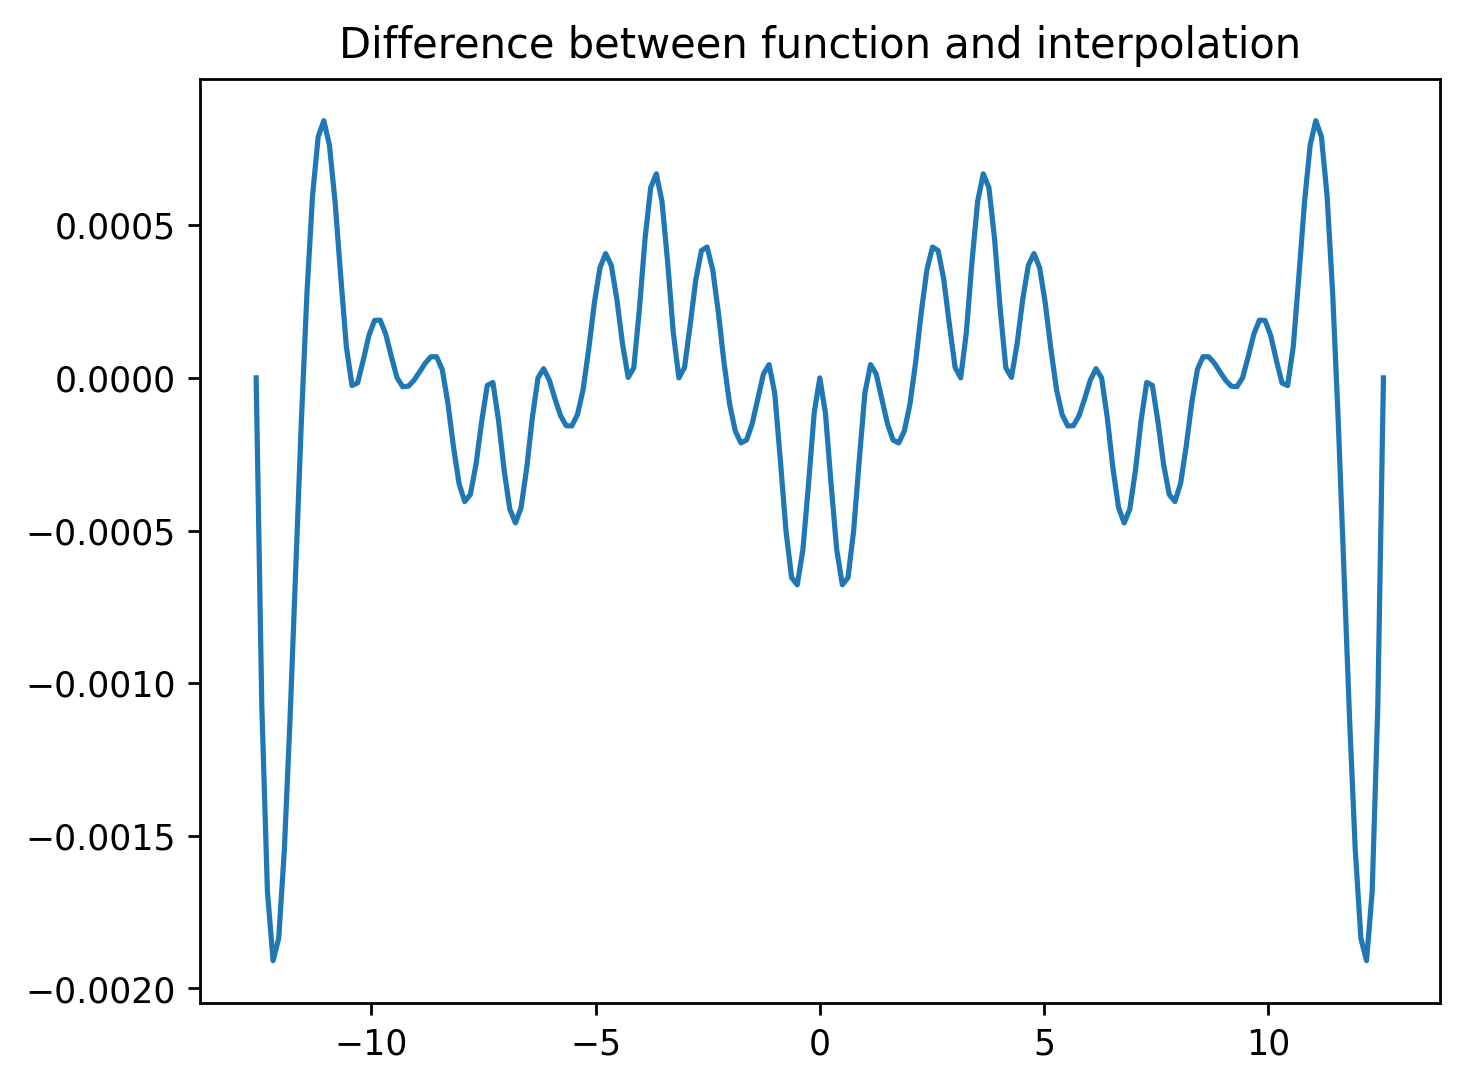

In [22]:
plt.plot(x,spline(x)-sinc(x))
plt.title("Difference between function and interpolation")
plt.show()

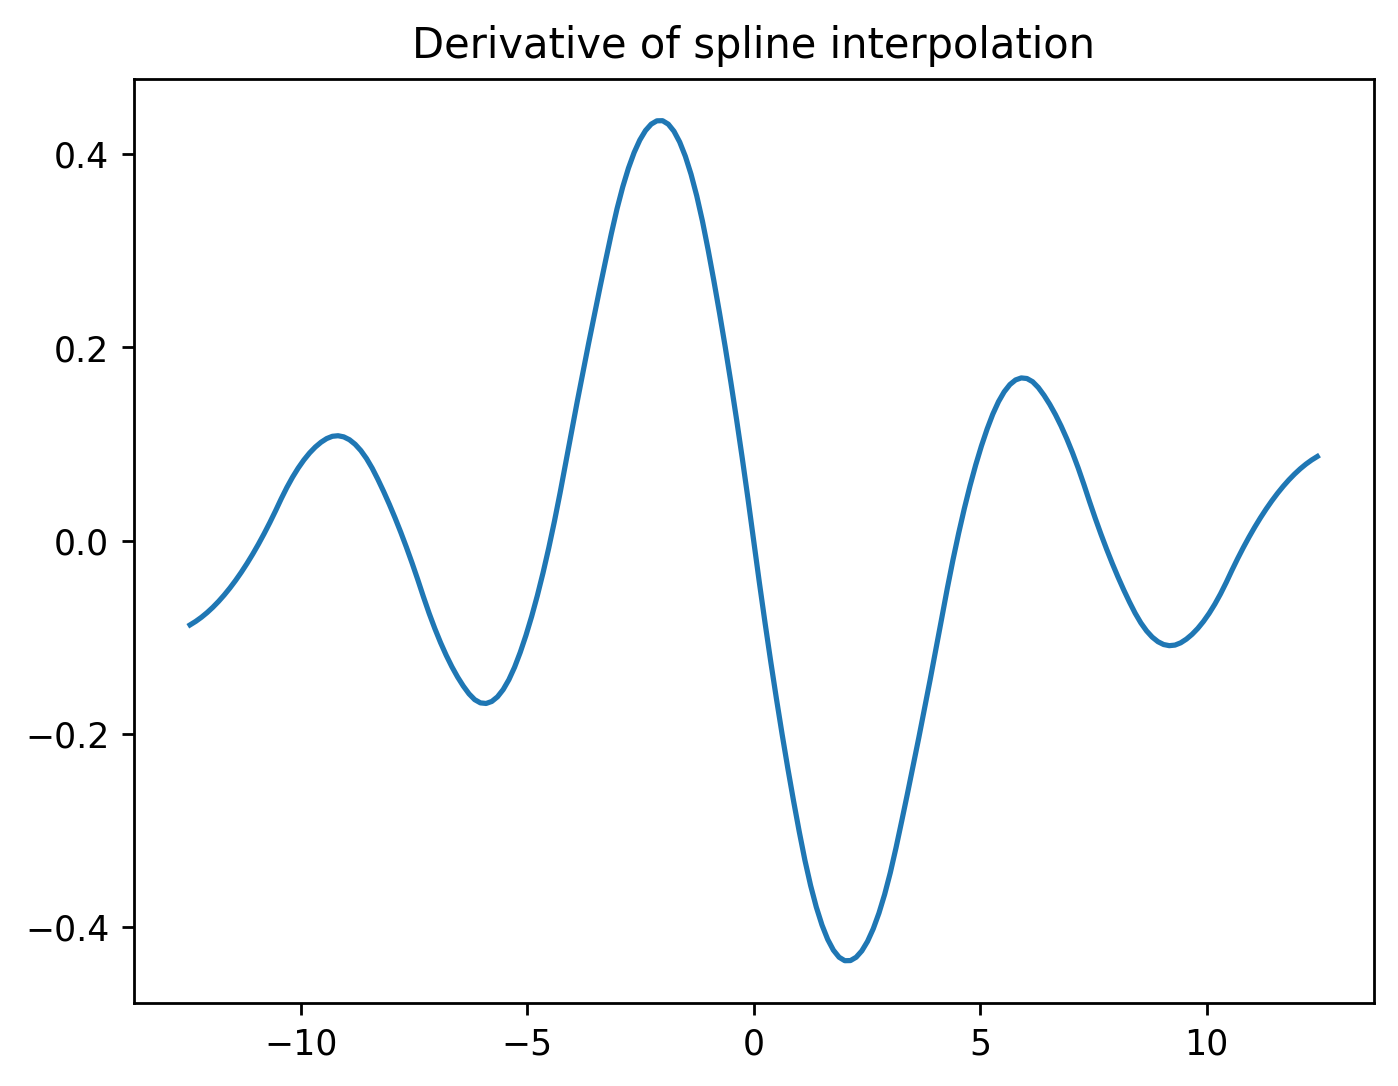

In [23]:
plt.plot(x[1:-1],derivative(spline,x[1:-1]))
plt.title("Derivative of spline interpolation")
plt.show()

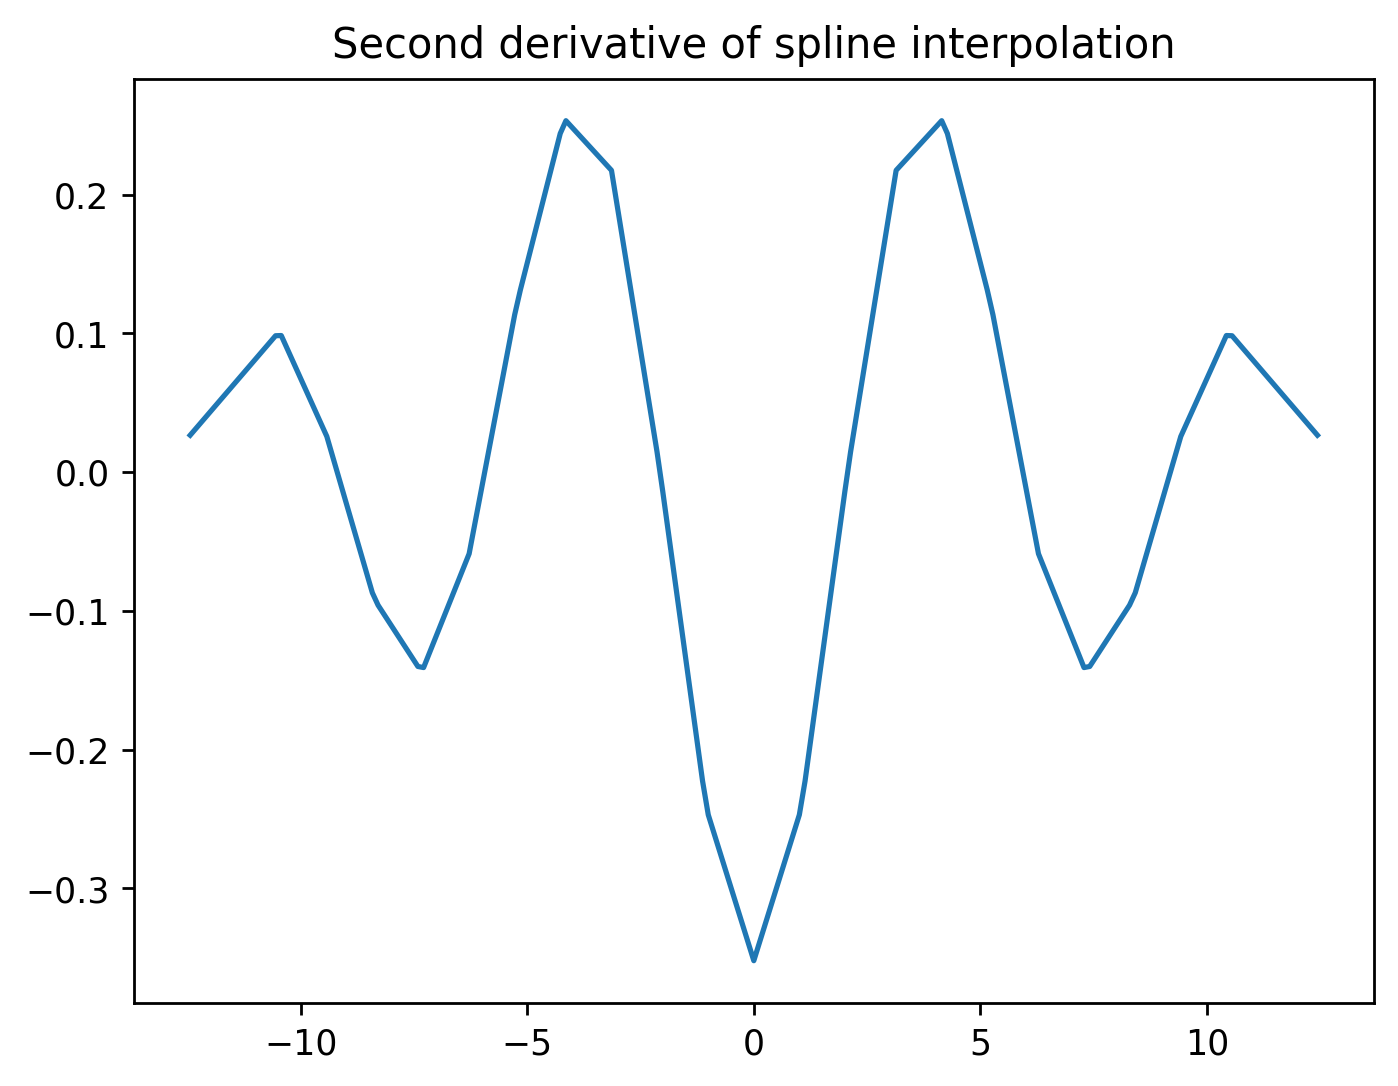

In [24]:
def doubleD(x):
    return derivative(spline,x)


plt.plot(x[1:-1],derivative(doubleD,x[1:-1]))
plt.title("Second derivative of spline interpolation")
plt.show()

# Polynomial Interpolation

We can also look for a polynomial that passes through all the points in the table of values.  We are all familiar with the Lagrange formula for finding a polynomial that passes through the points $(x_i,y_i):$
$$ p(x)=\sum_{i=0}^N f(x)\frac{\prod_{k=0,k\ne i}^N x-x_k}{\prod_{k=0,k\ne i}^N x_i-x_k}$$


$$=\prod_{k=0}^N (x-x_k)\left(\sum_{i=0}^{N}f_i \frac{w_i}{x-x_i}\right), \rm{ with\ } w_i=\frac{1}{\prod_{k=0,k\ne i}^N x_i-x_k}$$.
And a trick-- apply this to the function f(x)=1.  Then

$$1=\prod_{k=0}^N (x-x_k)\left(\sum_{i=0}^{N} \frac{w_i}{x-x_i}\right)$$

finally
$$p(x)=\frac{\sum_{i=0}^{N}f_i \frac{w_i}{x-x_i}}{\sum_{i=0}^{N}\frac{w_i}{x-x_i}}$$


This is just the Lagrange formula, with some algebra, but this form is called the "Barycentric Formula".  
Notice that the weights just depend upon the x-values where the function is evaluated, and there are various schemes for picking those values.  

Your "go-to" values should be the zero-s of the Chebyshev polynomials. If you are interested in a further discussion, see section 5.8 in Numerical Recipes.  The bottom line is that the Chebyshev approximation has two very desireable features:
     1. For a given order, it is very close to the "minimax polynomial", defined as the polynomial with the smallest maximum deviation from the true function.
     2. If you calculate it for a high order, and then truncate to a lower degree you end up with something very close to the optimum polynomial.

In [14]:
from scipy.interpolate import BarycentricInterpolator
help(BarycentricInterpolator)

Help on class BarycentricInterpolator in module scipy.interpolate._polyint:

class BarycentricInterpolator(_Interpolator1DWithDerivatives)
 |  BarycentricInterpolator(xi, yi=None, axis=0, *, wi=None, random_state=None)
 |  
 |  Interpolating polynomial for a set of points.
 |  
 |  Constructs a polynomial that passes through a given set of points.
 |  Allows evaluation of the polynomial and all its derivatives,
 |  efficient changing of the y-values to be interpolated,
 |  and updating by adding more x- and y-values.
 |  
 |  For reasons of numerical stability, this function does not compute
 |  the coefficients of the polynomial.
 |  
 |  The values `yi` need to be provided before the function is
 |  evaluated, but none of the preprocessing depends on them, so rapid
 |  updates are possible.
 |  
 |  Parameters
 |  ----------
 |  xi : array_like, shape (npoints, )
 |      1-D array of x coordinates of the points the polynomial
 |      should pass through
 |  yi : array_like, shape (..

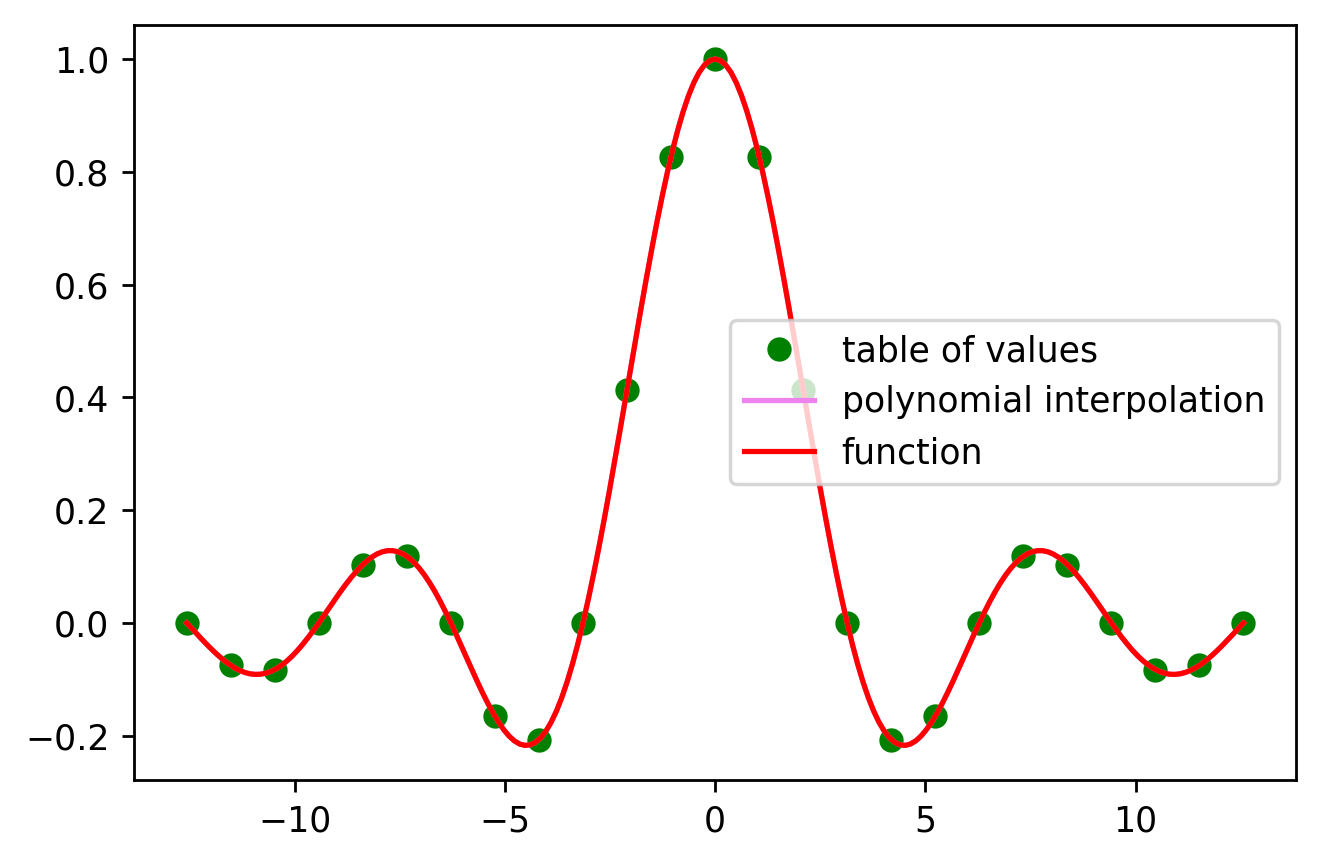

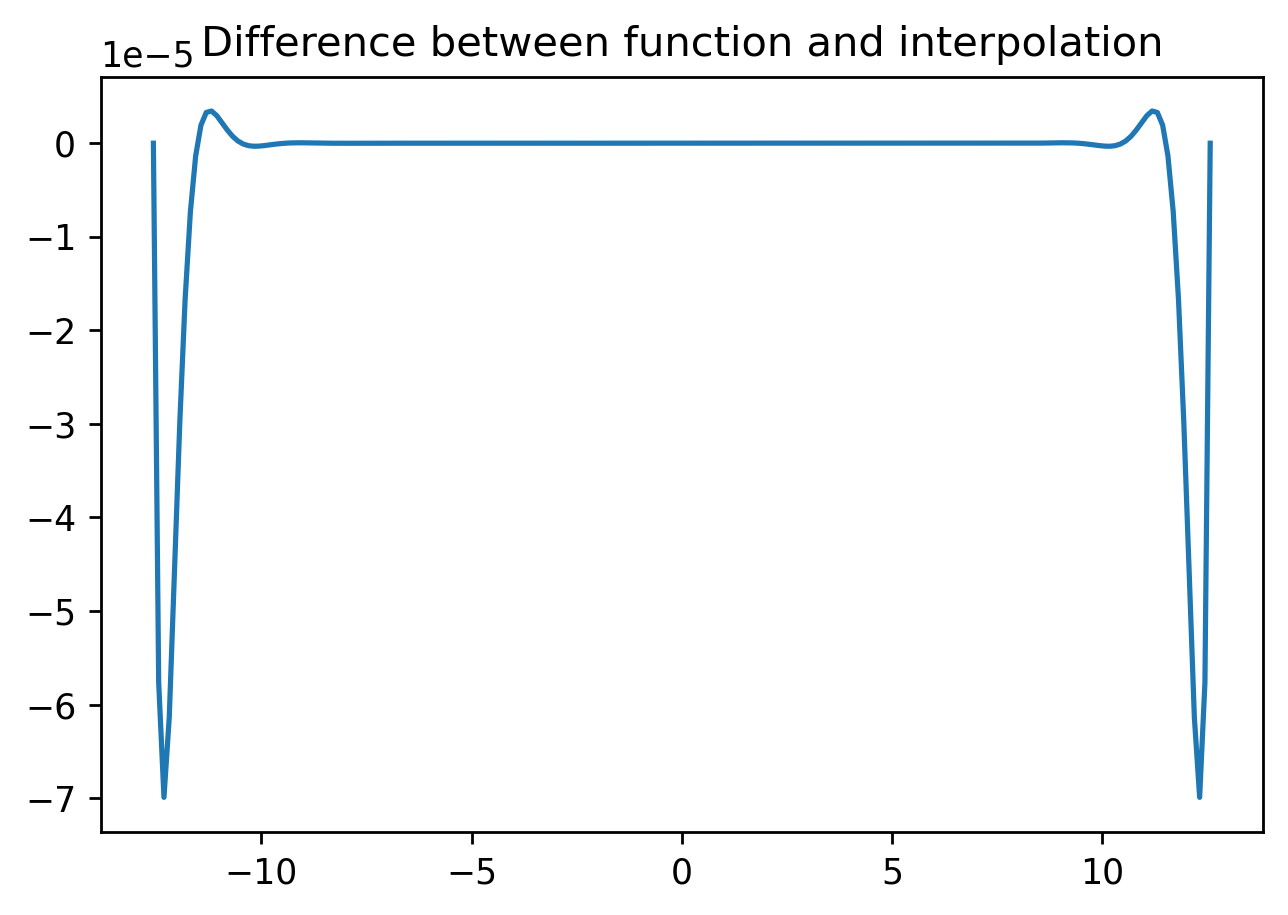

In [15]:
# If necessary, we start with our table of values

bary=BarycentricInterpolator(tablex,tabley)

plt.plot(tablex,tabley,'o',color='green',label='table of values')
plt.plot(x,bary(x),color='violet',label='polynomial interpolation')
plt.plot(x,sinc(x),color='red',label='function')
plt.legend()
plt.show()

plt.plot(x,bary(x)-sinc(x))
plt.title("Difference between function and interpolation")
plt.show()

The big deviations at the end are because of the constant delta-x values.  Polynomial interpolation is much better with higher density of points towards the outside.  

In [16]:
#now we define table values that correspond to zeros of a chebyshev polynomial-- cos(i*pi/n).  
#We plot curves for N=5,10,20,40,80

def ch(N):
    x=4*np.pi*np.cos(np.linspace(0,N,N+1)*np.pi/N)
    y=sinc(x)
    return BarycentricInterpolator(x,y)

In [17]:
N=10
4*np.pi*np.cos(np.linspace(0,N,N+1)*np.pi/N)

array([ 1.25663706e+01,  1.19513287e+01,  1.01664074e+01,  7.38632732e+00,
        3.88322208e+00,  7.69468277e-16, -3.88322208e+00, -7.38632732e+00,
       -1.01664074e+01, -1.19513287e+01, -1.25663706e+01])

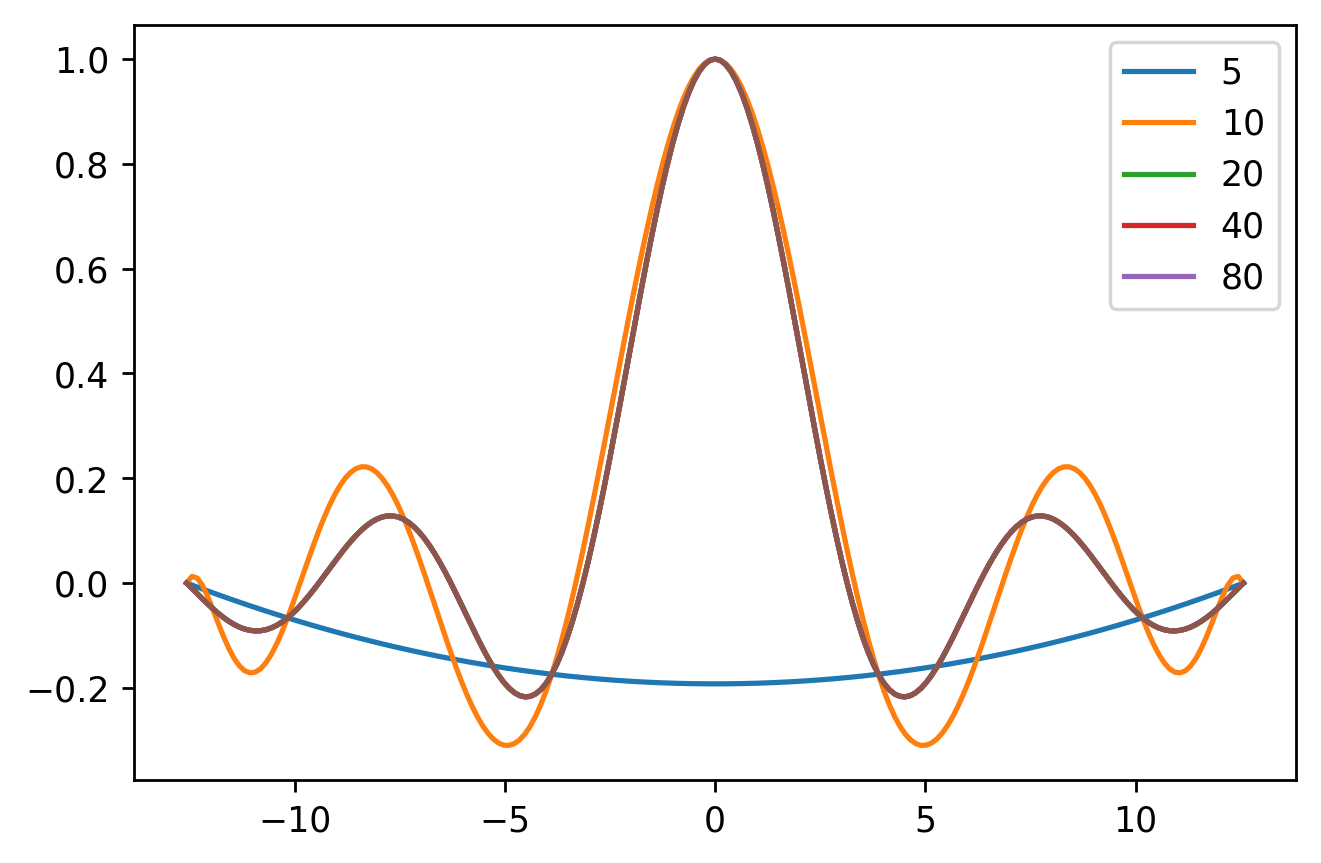

In [18]:
for n in [5,10,20,40,80]:
    interp=ch(n)
    plt.plot(x,interp(x),label=f'{n}')

plt.plot(x,sinc(x))
plt.legend()
plt.show()

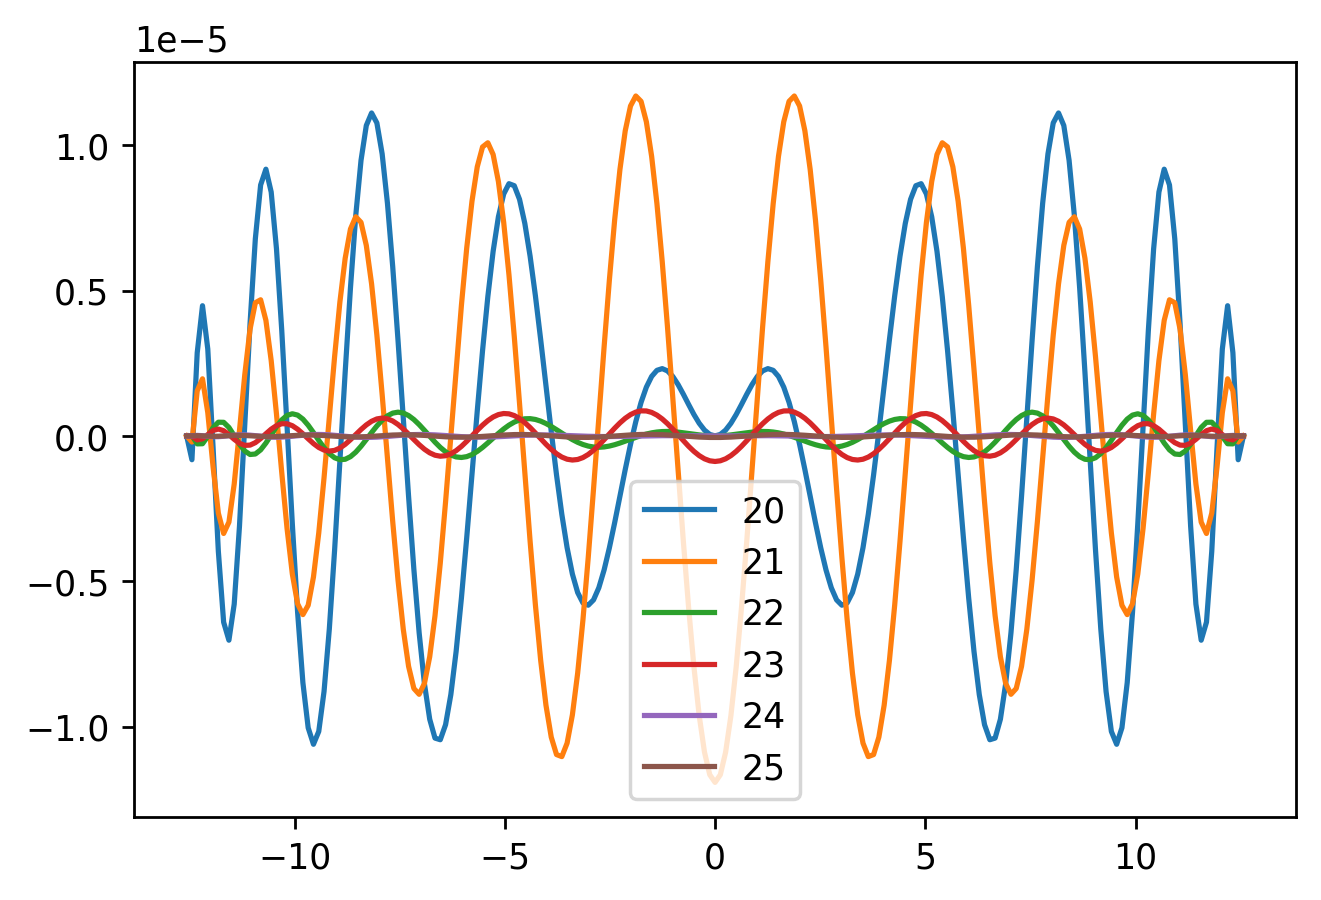

In [19]:
for n in [20,21,22,23,24,25]:
    interp=ch(n)
    plt.plot(x,interp(x)-sinc(x),label=f'{n}')

plt.legend()
plt.show()

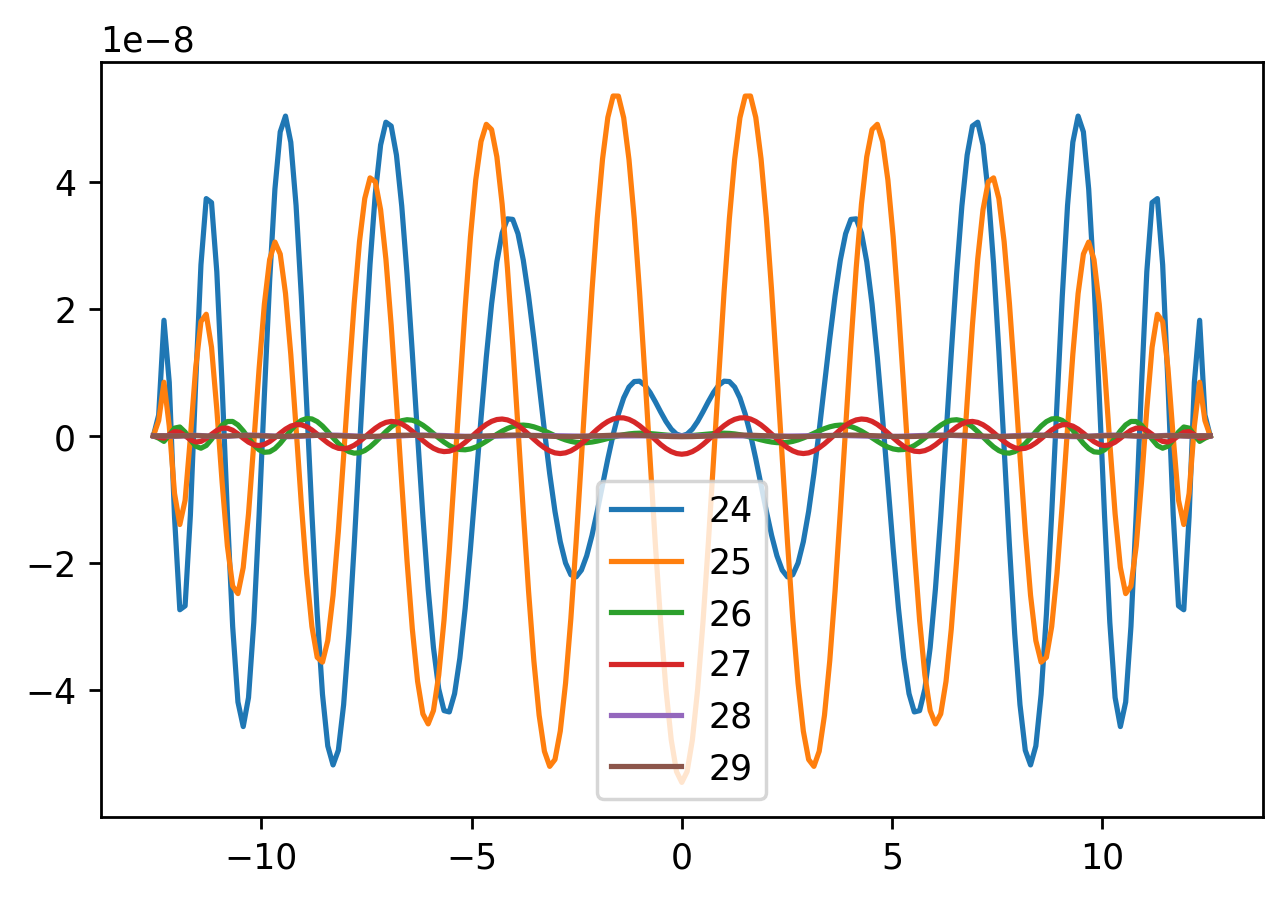

In [20]:
for n in [24,25,26,27,28,29]:
    interp=ch(n)
    plt.plot(x,interp(x)-sinc(x),label=f'{n}')

plt.legend()
plt.show()

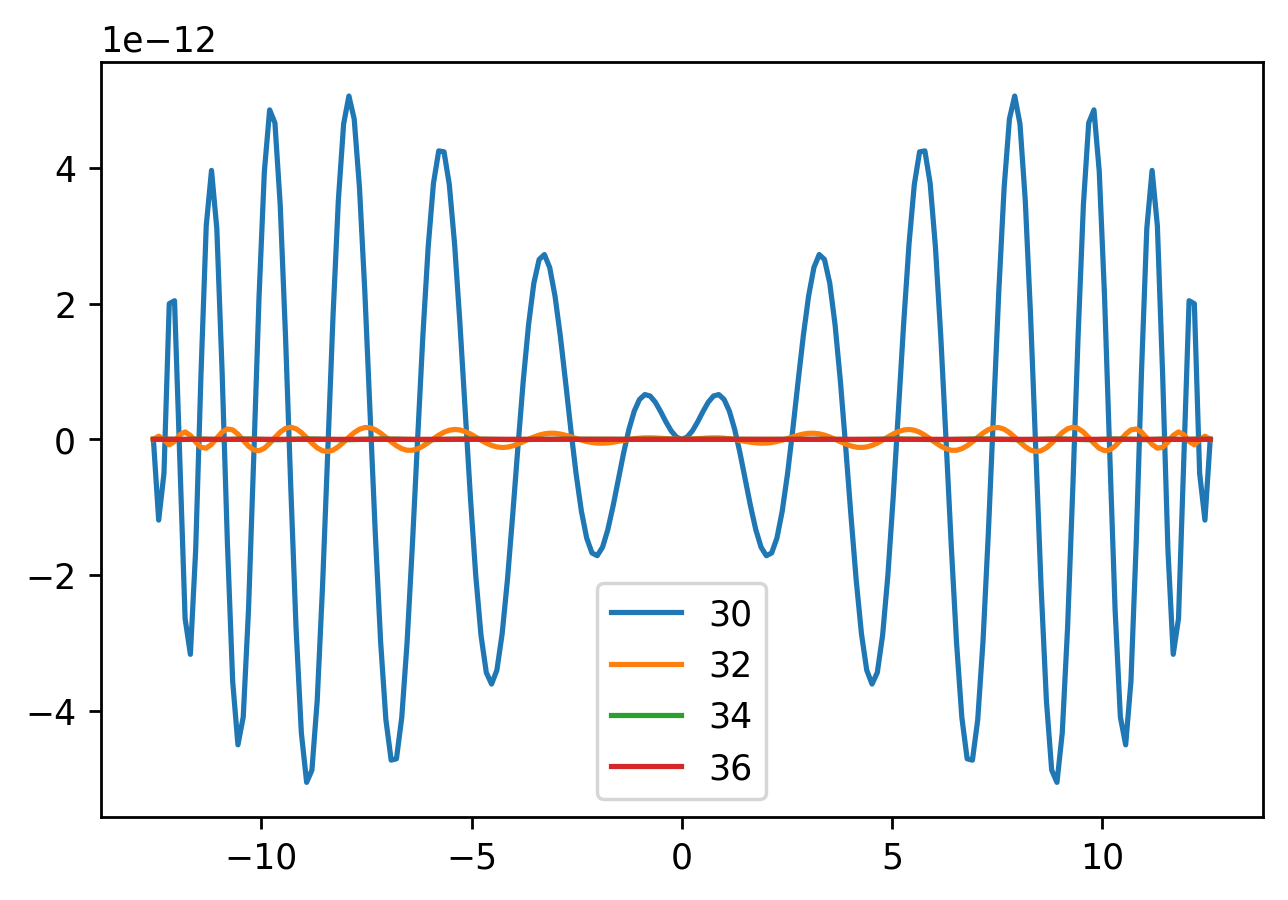

In [21]:
for n in [30,32,34,36]:
    interp=ch(n)
    plt.plot(x,interp(x)-sinc(x),label=f'{n}')

plt.legend()
plt.show()

In [22]:
# Now let's interpolate the triangle wave

#now we define table values that correspond to zeros of a chebyshev polynomial-- cos(i*pi/n).  
#We plot curves for N=5,10,20,40,80

def triang(N):
    x=np.cos(np.linspace(0,N,N+1)*np.pi/N)
    y=triangle(x)
    return BarycentricInterpolator(x,y)

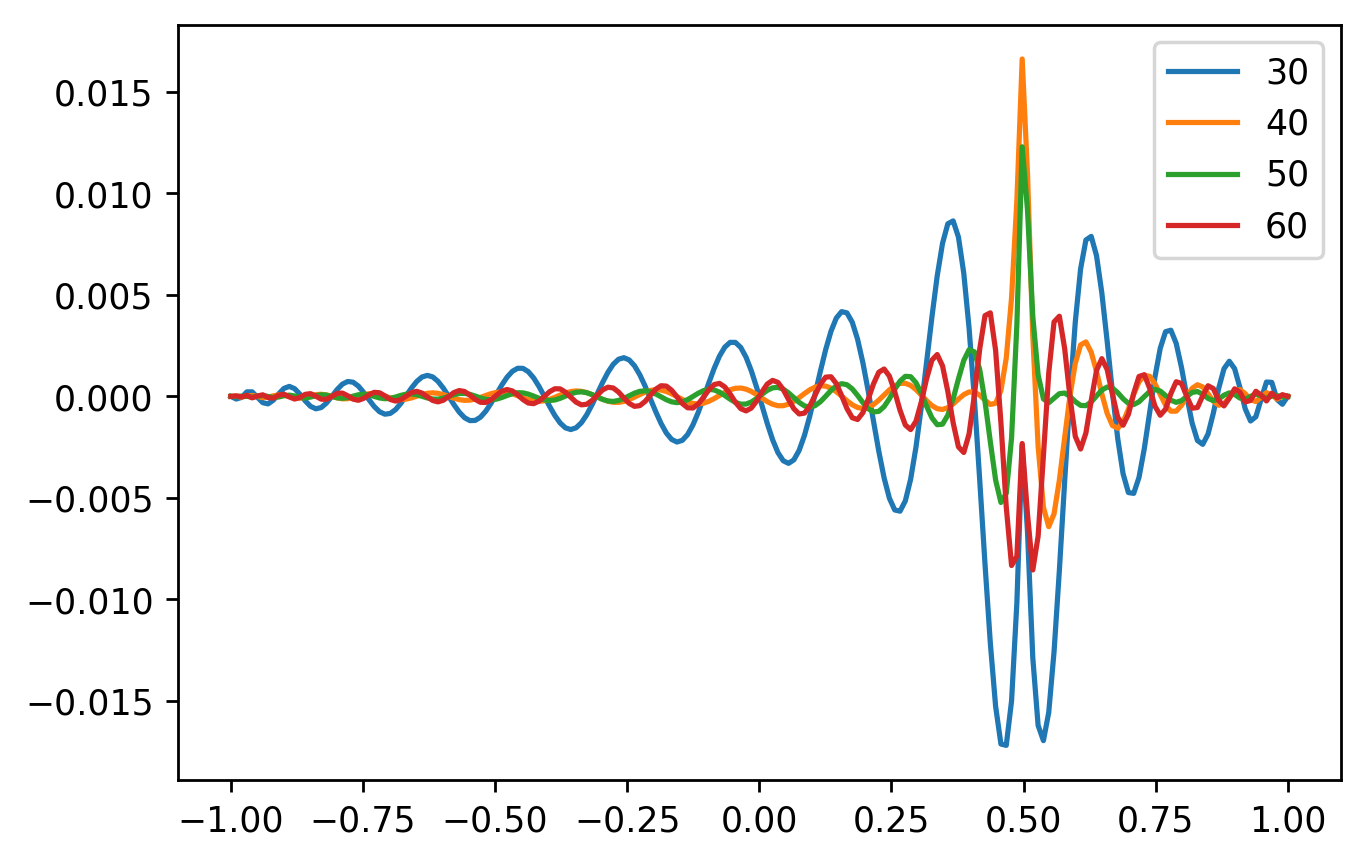

In [23]:
for n in [30,40,50,60]:
    interp=triang(n)
    plt.plot(xt,triangle(xt)-interp(xt),label=f'{n}')

plt.legend()
plt.show()

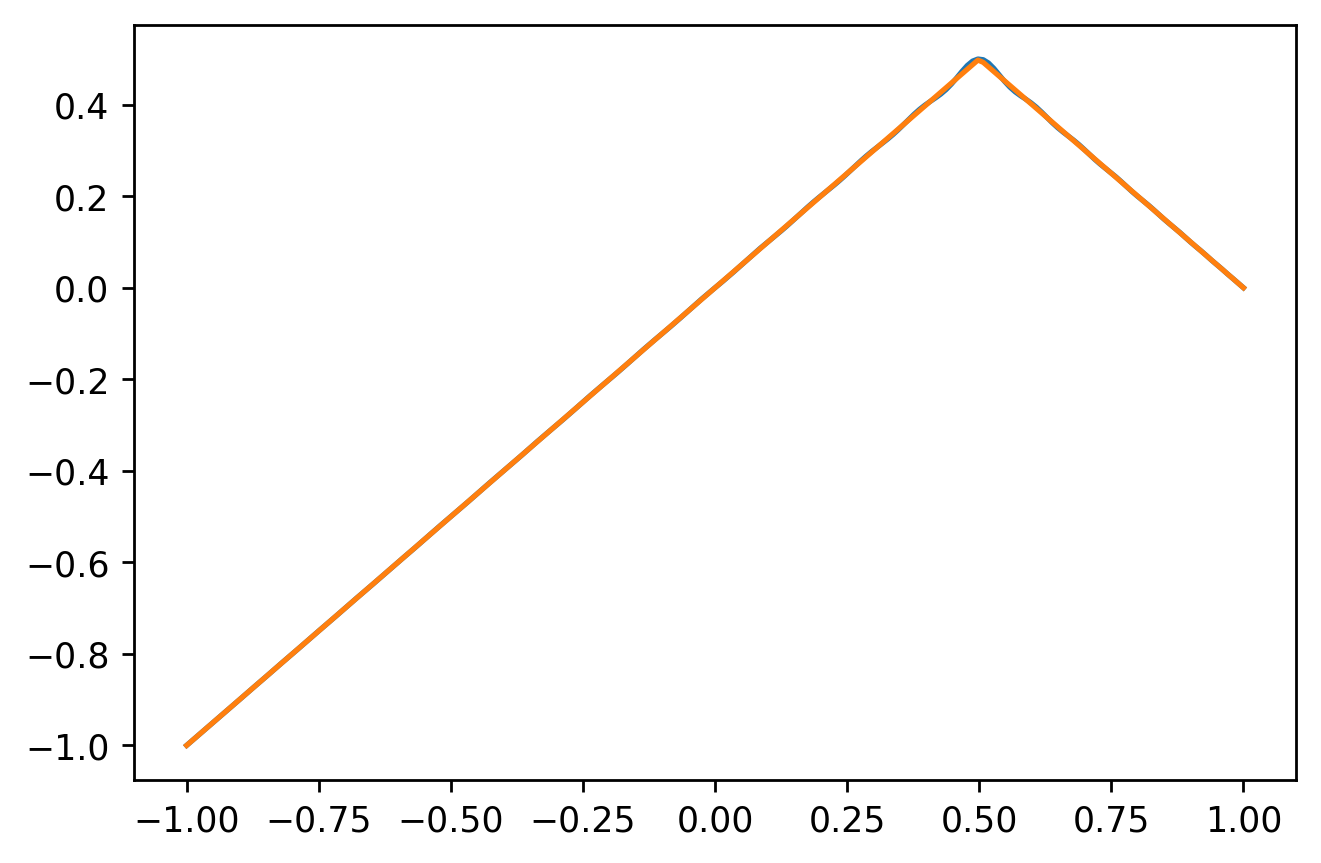

In [24]:
interp=triang(60)
plt.plot(xt,interp(xt))
plt.plot(xt,triangle(xt))
plt.show()

The triangle wave has a discontinuous derivative, so it can't be approximated by a single polynomial.  (Even though if we broke it up into two parts it would be trivial to approximate exactly). 



# Comments on Interpolation

- It is straightforward to extend all these techniques to two or more dimensions.  
- If data cover many orders of magnitude, it is often better to interpolate the logarithm.
- If you know the general/limiting form of the function as a simple analytic calculation, it is often good to factor the function into analytic form * interpolation.
- If the function has known singularities/discontinuities break the interpolation up into multiple segments.
- It is often the case that you can save the interpolation values into a file and read them in later; saving long calculation times.

# Interpolate the Electric Potential 

We calculated the electric potential due to a charged rod.  Let's use some interpolation techniques to interpolate, and then compare the interpolated field to the calculated field.



In [25]:
import numpy as np
from scipy.integrate import dblquad, quad_vec
from scipy.constants import epsilon_0,pi #in SI units
CoulombFactor=1.0/(4*pi*epsilon_0)
chargeOnBar=100e-6 #Coulombs
rhoBar=0.01 #meters radius
zBar=1.0 #meters length
areaBar=2*pi*rhoBar**2+2*pi*rhoBar*zBar
sigma=chargeOnBar/areaBar #charge per unit area on bar

#integrand for voltage due to charge on the ends-- want to integrate over rho, phi
def V1(phi,rho,z,r):  #note dblquad wants func(y,x).  
    '''An integrand for the calculation of electrical potential from the end of a cylinder along the z axis
    Inputs phi,rho are the cylindrical position of the charge creating the field in a form to input to dblquad
    Input z is the position of the end.
    Input r is the position at which the field is evaluated.  It is a vector in cartesian coordinates.
    Output is the electric potential due to a charge distribution with charge per unit area sigma.'''
    rprime=np.array([rho*np.cos(phi),rho*np.sin(phi),z])
    distance=np.linalg.norm(r-rprime)
    return CoulombFactor*sigma*rho/distance #implicit drho dphi

#integrand for voltage due to charge on cylindrical surface- want to integrate over phi, z
def V2(z,phi,rho,r):
    '''An integrand for the calculation of electrical potential from a cylindrical surface along the z axis
    Inputs z,phi are the cylindrical position of the charge creating the field in a form to input to dblquad
    Input rho is the radius of the cylinder.
    Input r is the position at which the field is evaluated.  It is a vector in cartesian coordinates.
    Output is the electric potential due to a charge distribution with charge per unit area sigma.'''
    rprime=np.array([rho*np.cos(phi),rho*np.sin(phi),z])
    distance=np.linalg.norm(r-rprime)
    return CoulombFactor*sigma*rho/distance #implicit dphi dz

def V(r):
    '''Calculates electric potential at a point r from a cylinder
    Input r is the position where we evaluate the field, as a vector
    Output is the electric potential'''
    v=(dblquad(V1,0,rhoBar,0,2*pi,args=(-zBar/2.0,r))[0]+ 
    dblquad(V1,0,rhoBar,0,2*pi,args=(zBar/2.0,r))[0]+
    dblquad(V2,0,2*pi,-zBar/2.0,zBar/2,args=(rhoBar,r))[0])
    return v

def E(r):
    '''Calculates the Vector Electric field at position r'''
    global dx,dy,dz
    dx=5e-6*np.array([1,0,0]) #step size for integral
    dy=5e-6*np.array([0,1,0]) #step size for integral
    dz=5e-6*np.array([0,0,1]) #step size for integral
    rplus=r+dx
    rminus=r-dx
    E1=-(V(rplus)-V(rminus))/(rplus[0]-rminus[0])
    rplus=r+dy
    rminus=r-dy
    E2=-(V(rplus)-V(rminus))/(rplus[1]-rminus[1])
    rplus=r+dz
    rminus=r-dz
    E3=-(V(rplus)-V(rminus))/(rplus[2]-rminus[2])
    return np.array([E1,E2,E3])
    
def Ex(r):
    'Calculate X component of Efield at position r'
    dx=5e-6*np.array([1,0,0]) #step size for integral
    rplus=r+dx
    rminus=r-dx
    xE=-(V(rplus)-V(rminus))/(rplus[0]-rminus[0])
    return xE

def Ez(r):
    'Calculate Z component of Efield at position r'
    dz=5e-6*np.array([0,0,1]) #step size for integral
    rplus=r+dz
    rminus=r-dz
    zE=-(V(rplus)-V(rminus))/(rplus[2]-rminus[2])
    return zE


Elapsed time was  26.012288314001125


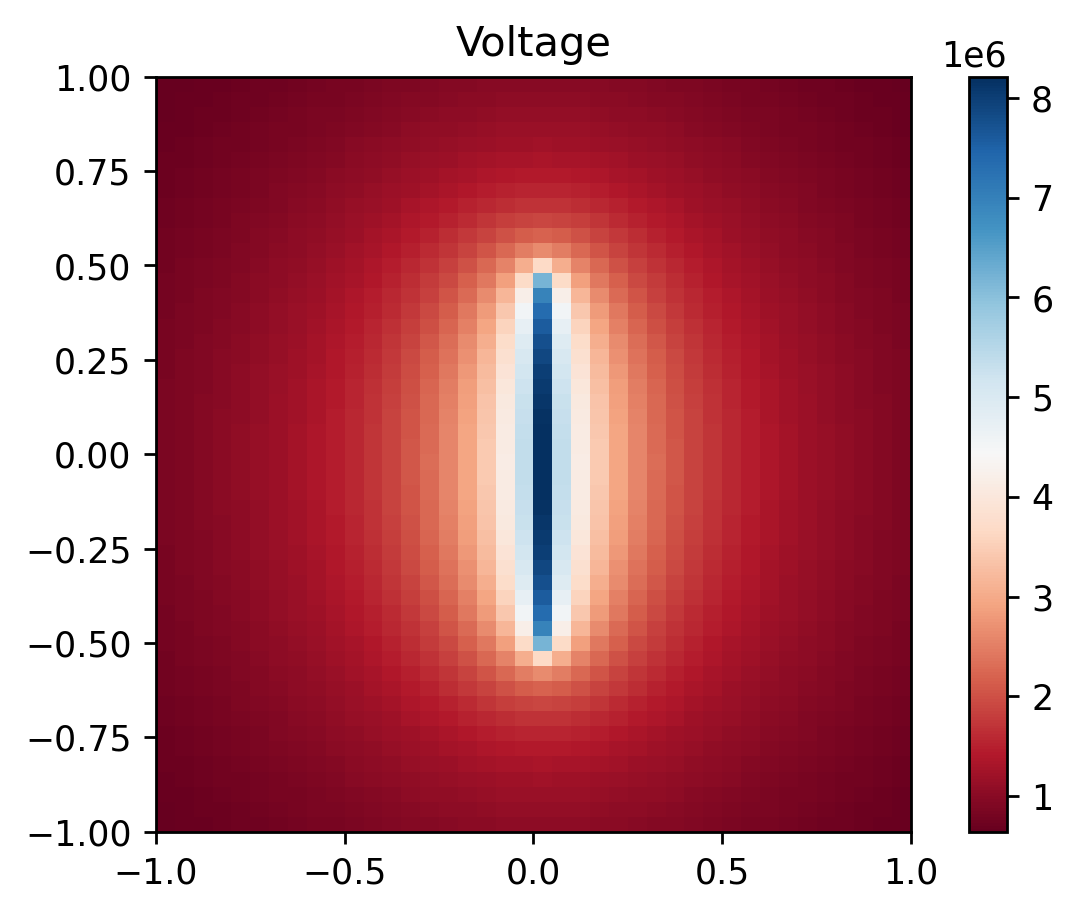

In [26]:
import matplotlib.pyplot as plt #import meshgrid,cm,imshow,contour,clabel,colorbar,axis,title,show
import timeit

startTime=timeit.default_timer()
def voltage(x,z):
    r=np.array([x,0,z])
    return V(r)
x = np.arange(-1.0,1.0,0.05)
y = np.arange(-1.0,1.0,0.04)
X,Y = np.meshgrid(x, y, indexing='xy') # grid of point
volt2=np.vectorize(voltage)
Z = volt2(X,Y) # evaluation of the function on the grid

elapsedTime=timeit.default_timer()-startTime
print('Elapsed time was ',elapsedTime)
im = plt.imshow(Z,cmap=plt.cm.RdBu,extent=[-1,1,-1,1]) # drawing the function
plt.colorbar(im) # adding the colobar on the right
plt.title('Voltage')
plt.show()


In [37]:
# Do this if we have scipy 1.10

from scipy.interpolate import RegularGridInterpolator
rgi=RegularGridInterpolator((y,x),Z,method='cubic',bounds_error=False)   #need to reverse order because meshgrid
#mode for imshow is opposite to that for RGI

In [38]:
#Set up an interpolation grid for the field.  

from scipy.interpolate import RectBivariateSpline
bvs=RectBivariateSpline(y,x,Z)

In [156]:
#scipy 1.10
#help(RegularGridInterpolator)
#input=[np.array(pt) for pt in zip(X2.flatten(),Y2.flatten())]
#out=rgi(input).reshape(X2.shape)

In [157]:
help(RectBivariateSpline)

Help on class RectBivariateSpline in module scipy.interpolate.fitpack2:

class RectBivariateSpline(BivariateSpline)
 |  Bivariate spline approximation over a rectangular mesh.
 |  
 |  Can be used for both smoothing and interpolating data.
 |  
 |  Parameters
 |  ----------
 |  x,y : array_like
 |      1-D arrays of coordinates in strictly ascending order.
 |  z : array_like
 |      2-D array of data with shape (x.size,y.size).
 |  bbox : array_like, optional
 |      Sequence of length 4 specifying the boundary of the rectangular
 |      approximation domain.  By default,
 |      ``bbox=[min(x,tx),max(x,tx), min(y,ty),max(y,ty)]``.
 |  kx, ky : ints, optional
 |      Degrees of the bivariate spline. Default is 3.
 |  s : float, optional
 |      Positive smoothing factor defined for estimation condition:
 |      ``sum((w[i]*(z[i]-s(x[i], y[i])))**2, axis=0) <= s``
 |      Default is ``s=0``, which is for interpolation.
 |  
 |  See Also
 |  --------
 |  SmoothBivariateSpline : a smoothi

Elapsed time= 0.438384782999492


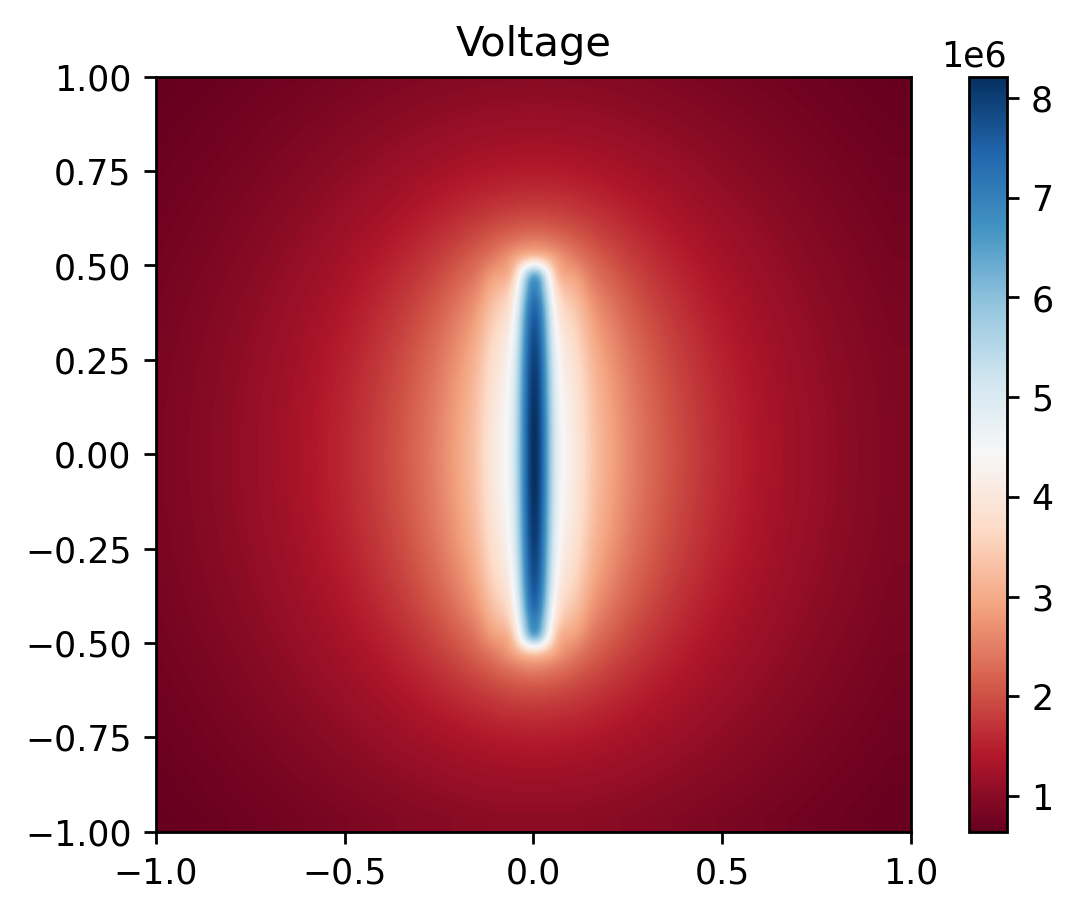

In [40]:
startTime=timeit.default_timer()
x = np.arange(-1.0,1.0,0.005)
y = np.arange(-1.0,1.0,0.005)
X2,Y2 = np.meshgrid(x, y) # grid of point

# rgi wants an array of x,y values, not an array of X values followed by an array of Y values.
# We use zip, and remember we need to flip the order in rgi.
#Z2=rgi([np.array(pt) for pt in zip(Y2.flatten(),X2.flatten())]).reshape(X2.shape)
Z2=np.array([[bvs(xx,yy)[0][0] for yy in y]for xx in x])
elapsedTime=timeit.default_timer()-startTime
print('Elapsed time=',elapsedTime)
im = plt.imshow(Z2,cmap=plt.cm.RdBu,extent=[-1,1,-1,1]) # drawing the function
plt.colorbar(im) # adding the colobar on the right
plt.title('Voltage')
plt.show()


The plot looks nicer,- it is 400x400 compared to 40x50 but is it accurate?  Or just smooth?  To test that, we will calculate a line at, say x=0.03 m, and another at z=0 and compare the interpolation to the actual function.

In [41]:
z=np.arange(0,1,0.005)
v=np.array([voltage(0.03,zz) for zz in z])


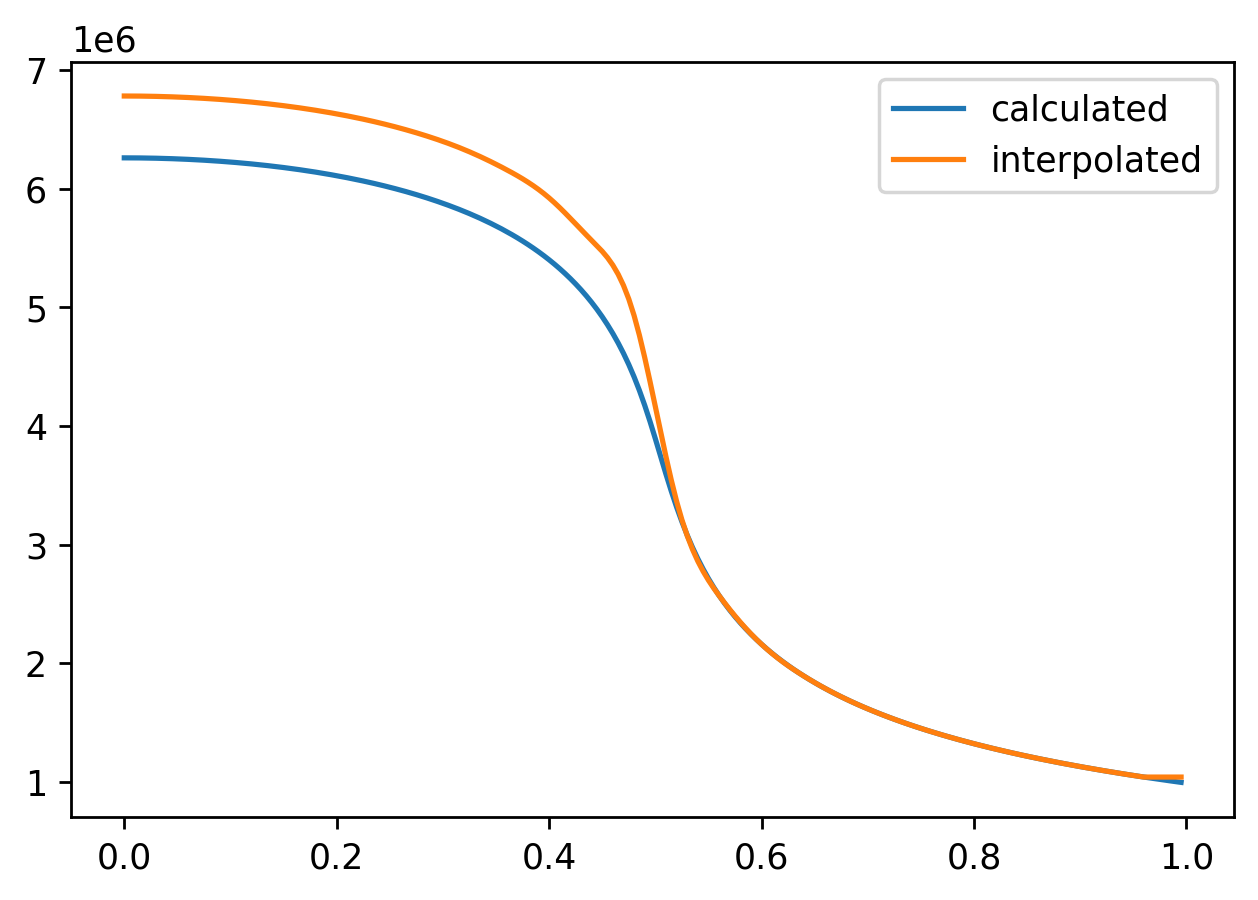

In [42]:
vinterp=np.array([bvs(zz,0.03)[0][0]for zz in z])
plt.plot(z,v,label='calculated')
plt.plot(z,vinterp,label='interpolated')
plt.legend()
plt.show()

In [43]:
x=np.arange(0,1,0.005)
vx=np.array([voltage(xx,0.03) for xx in x])


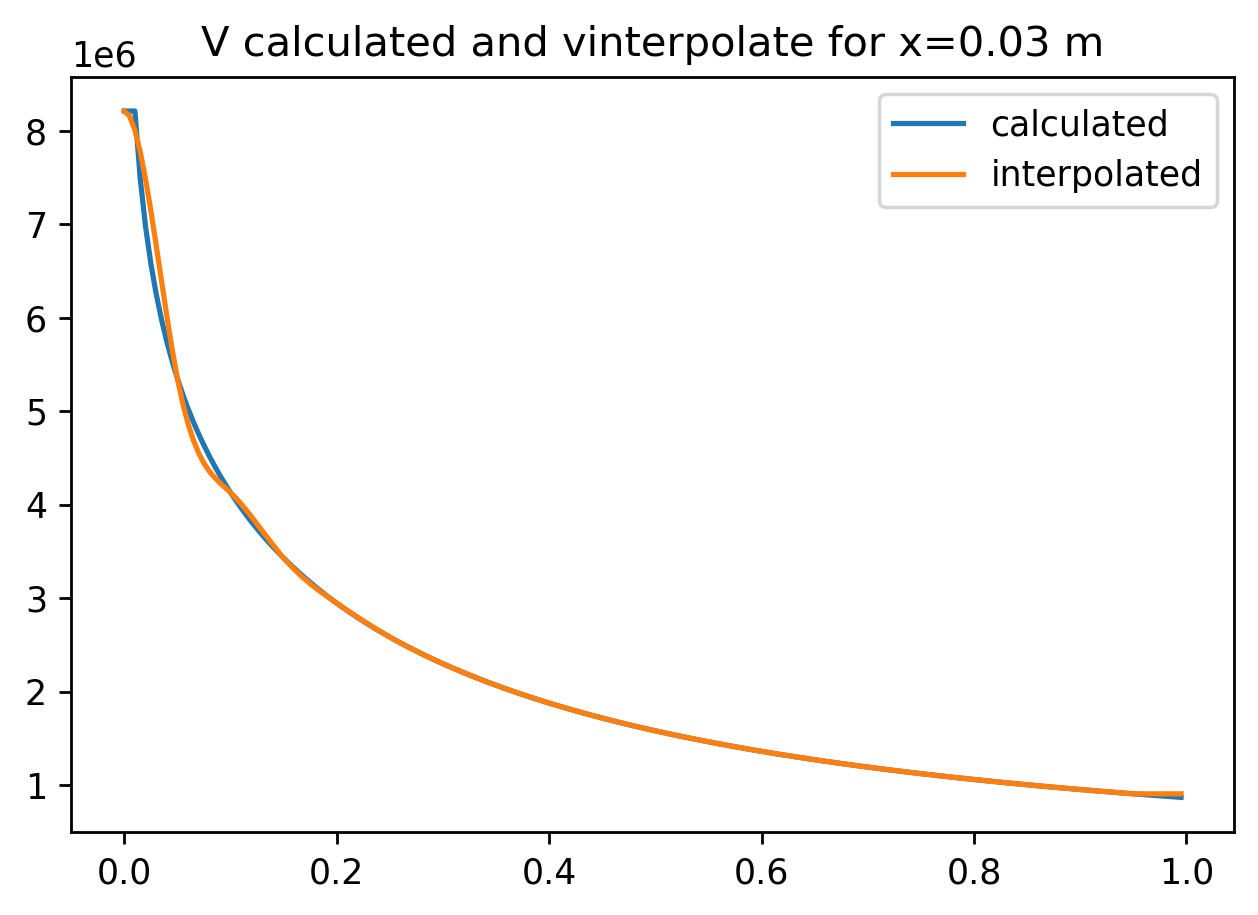

In [44]:
vinterp=np.array([bvs(0.03,zz)[0][0]for zz in z])
plt.title("V calculated and vinterpolate for x=0.03 m")
plt.plot(x,vx,label='calculated')
plt.plot(x,vinterp,label='interpolated')
plt.legend()
plt.show()

Notice that the voltage has a discontinuous derivative at x=0.01.  We know that from the problem.  The insulated bar has radius 1 cm and length 0.5 meters.  So let's do a "piecewise" interpolation, starting with $\rho>0.01$ m.



Elapsed time was  33.46945666999818


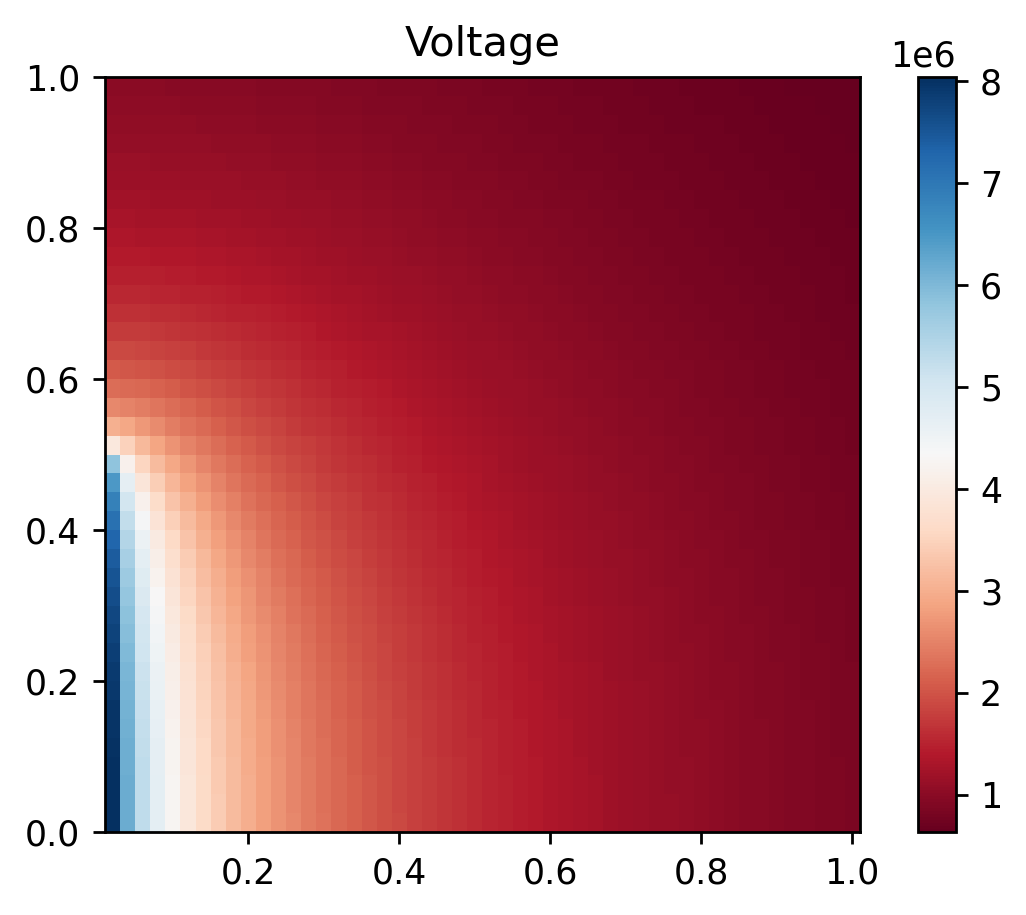

In [117]:
startTime=timeit.default_timer()
xl = np.linspace(0.011,1.011,50)
yl = np.linspace(0.0,1.0,40)
X,Y = np.meshgrid(xl, yl) # grid of point
Z = volt2(X,Y) # evaluation of the function on the grid

elapsedTime=timeit.default_timer()-startTime
print('Elapsed time was ',elapsedTime)
im = plt.imshow(Z,cmap=plt.cm.RdBu,extent=[0.01,1.01,0.0,1], origin='lower') # drawing the function
plt.colorbar(im) # adding the colobar on the right
plt.title('Voltage')
plt.show()

In [46]:
Z.shape

(40, 50)

Elapsed time= 0.11249865999707254


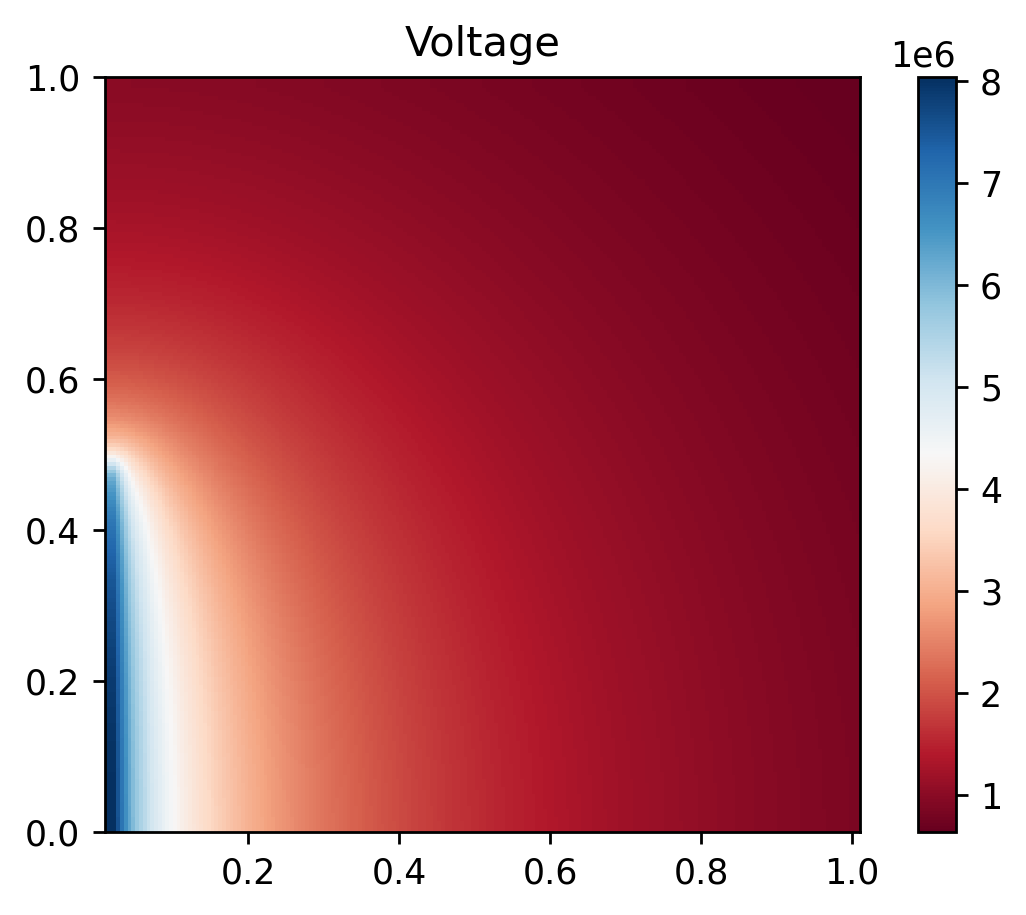

In [118]:
#rgi1=RegularGridInterpolator((yl,xl),Z,method='cubic',bounds_error=False) # spline outside the rod radius

bvs1=RectBivariateSpline(yl,xl,Z)

startTime=timeit.default_timer()
x = np.linspace(0.011,1.011,200)
y = np.linspace(0.0,1.0,200)
X2,Y2 = np.meshgrid(x, y) # grid of point

#Z2=rgi1([np.array(pt) for pt in zip(Y2.flatten(),X2.flatten())]).reshape(X2.shape)
Z2=np.array([[bvs1(xx,yy)[0][0] for yy in y]for xx in x])
elapsedTime=timeit.default_timer()-startTime
print('Elapsed time=',elapsedTime)
im = plt.imshow(Z2,cmap=plt.cm.RdBu,extent=[0.01,1.01,0,1],origin='lower') # drawing the function
plt.colorbar(im) # adding the colobar on the right
plt.title('Voltage')
plt.show()



In [48]:
z=np.linspace(0.0,1.0,200)
v=np.array([voltage(0.03,zz) for zz in z])

In [2]:
vinterp=np.array([bvs1(zz,0.03)[0][0] for zz in z])
plt.title("Voltage along the z axis")
plt.plot(z,v,label='calculated')
plt.plot(z,vinterp,label='interpolated')
plt.legend()
plt.show()

NameError: name 'np' is not defined

In [3]:
print(vx.shape,vinterp.shape)
plt.title("V calculated - vinterpolate for x=0.03 m")
plt.plot(z,v-vinterp,label='calculated')
plt.xlabel('z')
plt.show()


NameError: name 'vx' is not defined

In [51]:
x=np.arange(0.011,1.011,0.005)
vx=np.array([voltage(xx,0.0) for xx in x])


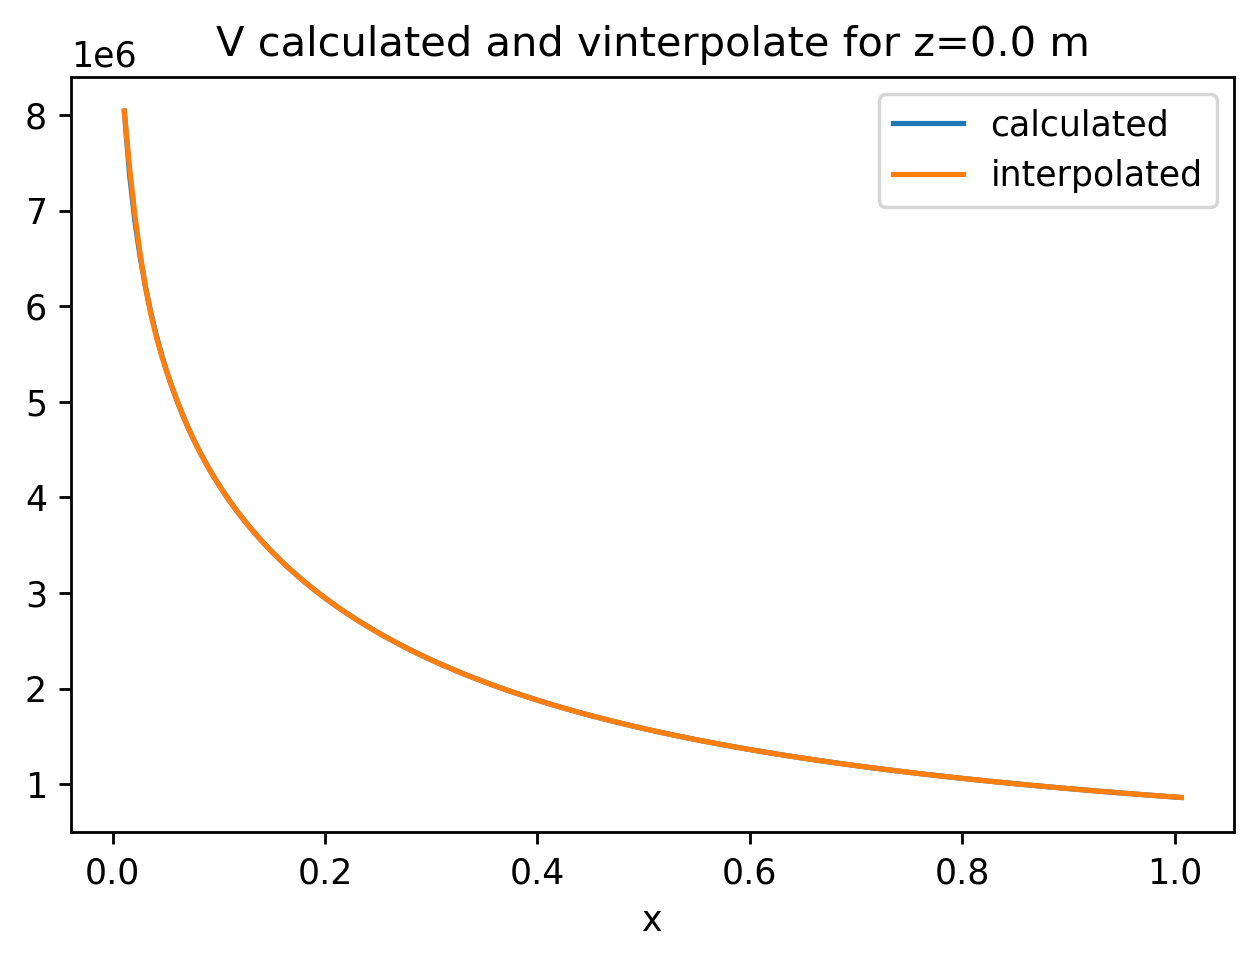

In [52]:
vinterp=np.array([bvs1(0.0,xx)[0][0]for xx in x])
plt.title("V calculated and vinterpolate for z=0.0 m")
plt.plot(x,vx,label='calculated')
plt.plot(x,vinterp,label='interpolated')
plt.xlabel('x')
plt.legend()
plt.show()

(200,) (200,)


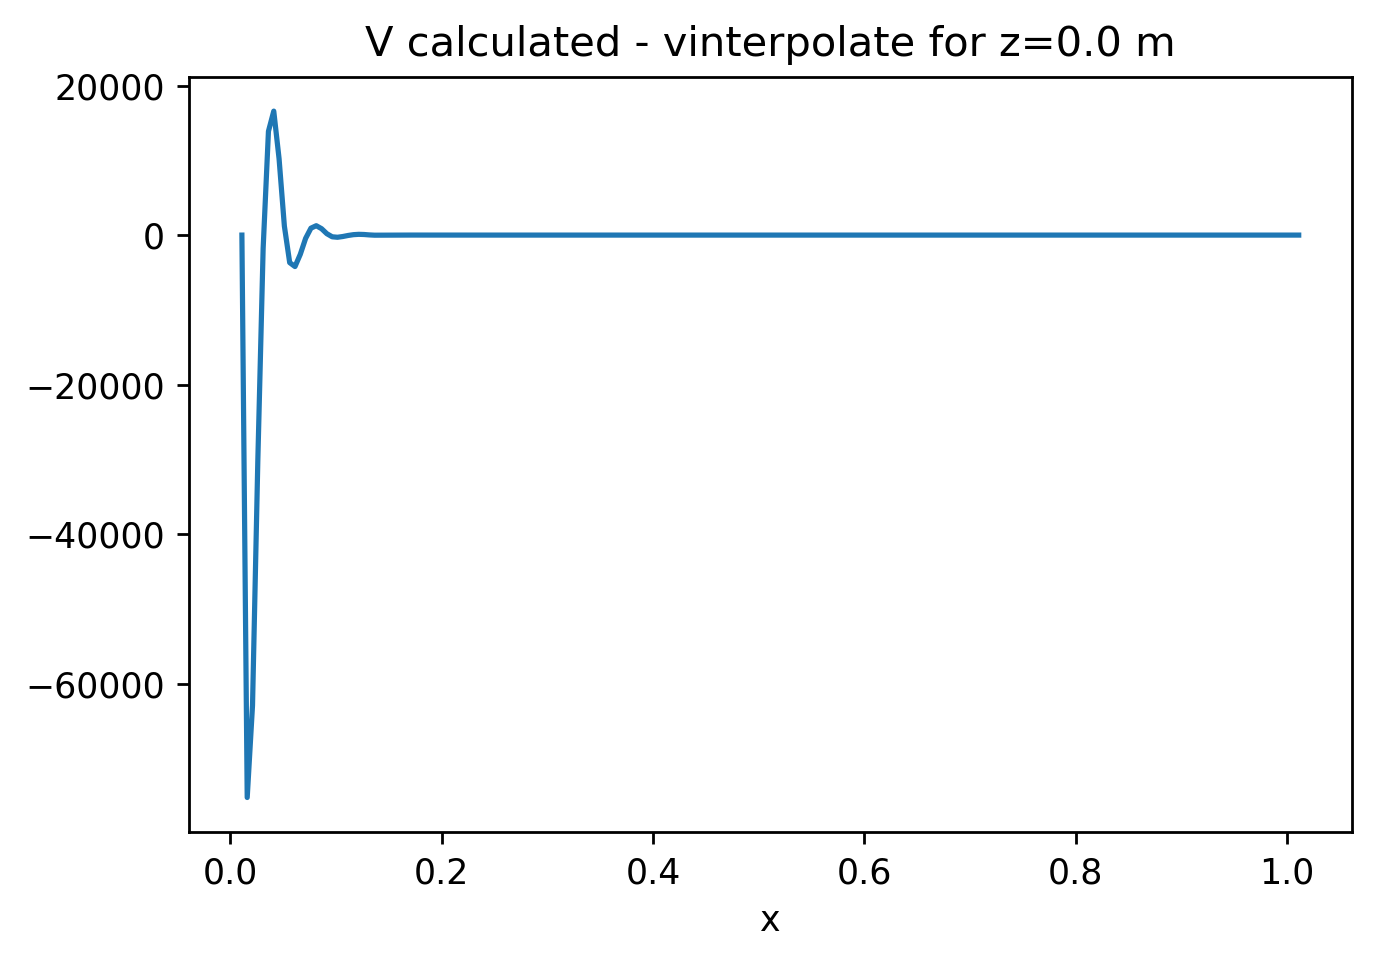

In [119]:
print(vx.shape,vinterp.shape)
plt.title("V calculated - vinterpolate for z=0.0 m")
plt.plot(x,vx-vinterp,label='calculated')
plt.xlabel('x')
plt.show()


# lnterpolate the logarithm

Just to demonstrate how to do this.  It actually doesn't add anything in this situation.

Elapsed time= 0.1408789240012993


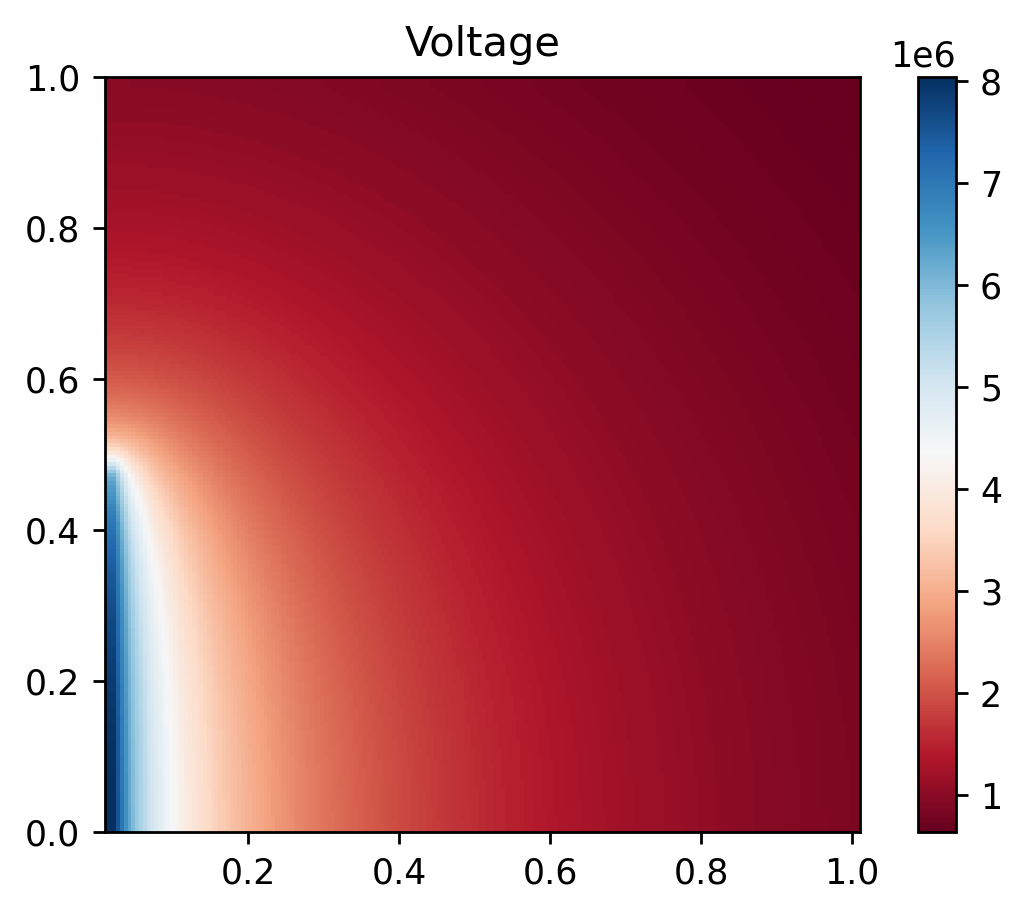

In [120]:
bvs2=RectBivariateSpline(yl,xl,np.log(Z)) # spline outside the rod radius
def rgiLog(xarg):
    return np.exp(bvs2(xarg[0],xarg[1])[0][0])

startTime=timeit.default_timer()
x = np.linspace(0.011,1.011,200)
y = np.linspace(0.0,1.0,200)
X2,Y2 = np.meshgrid(x, y) # grid of point

#Z2L=rgiLog([np.array(pt) for pt in zip(Y2.flatten(),X2.flatten())]).reshape(X2.shape)
Z2L=np.array([[np.exp(bvs2(xx,yy)[0][0])for yy in y]for xx in x])
elapsedTime=timeit.default_timer()-startTime
print('Elapsed time=',elapsedTime)
im = plt.imshow(Z2L,cmap=plt.cm.RdBu,extent=[0.01,1.01,0,1],origin='lower') # drawing the function
plt.colorbar(im) # adding the colobar on the right
plt.title('Voltage')
plt.show()

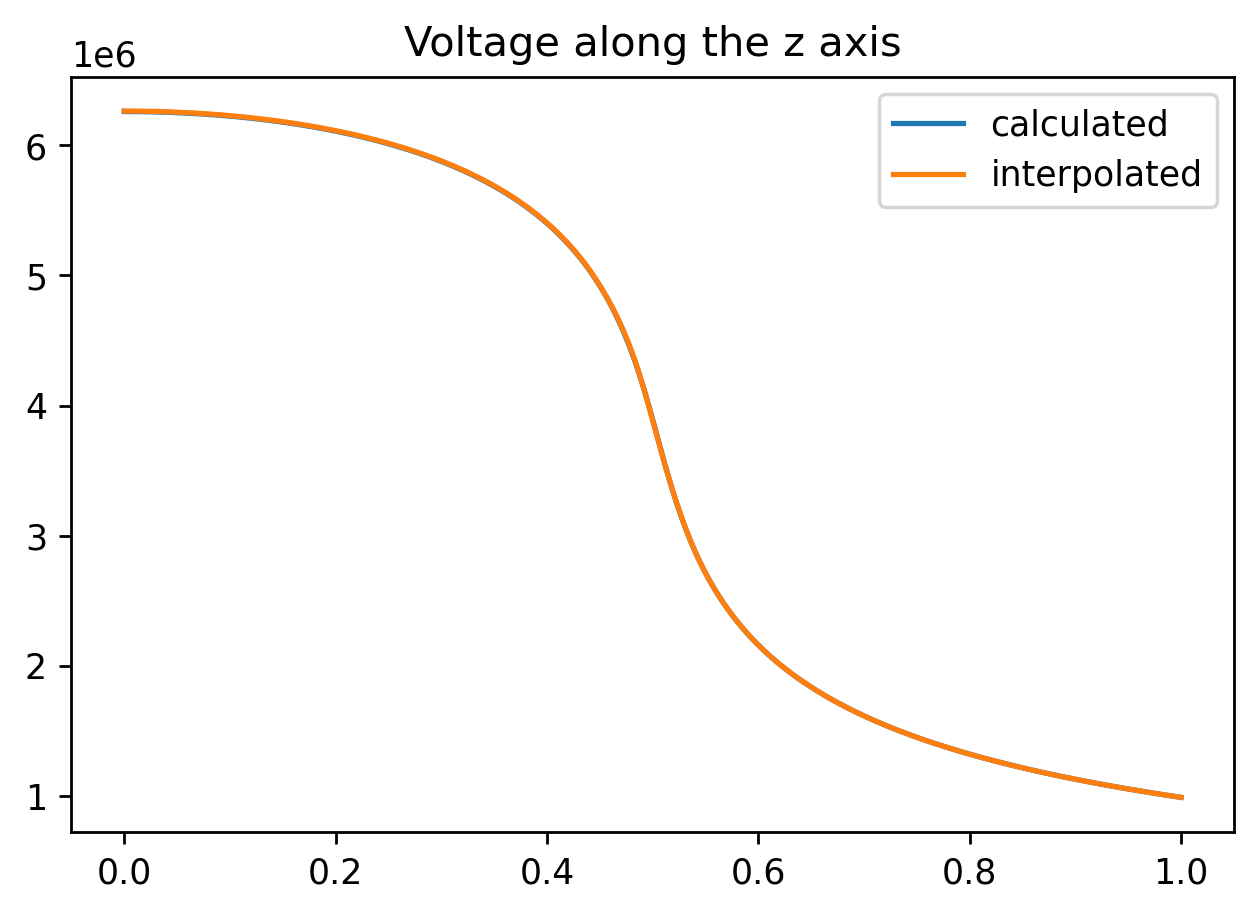

In [121]:
vinterp=np.array([rgiLog([zz,0.03])for zz in z])
plt.title("Voltage along the z axis")
plt.plot(z,v,label='calculated')
plt.plot(z,vinterp,label='interpolated')
plt.legend()
plt.show()

(200,) (200,)


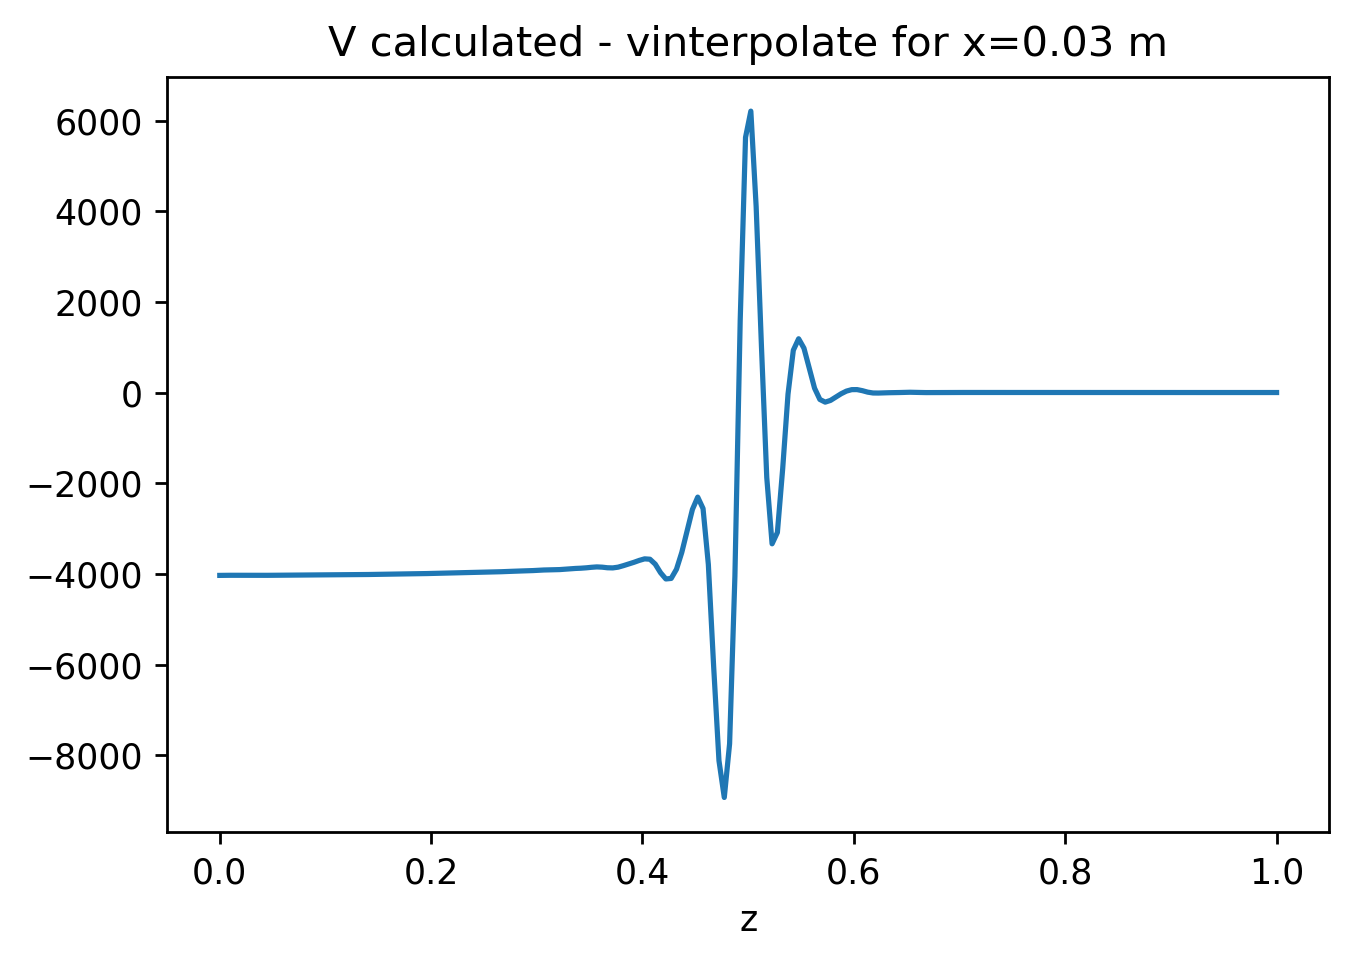

In [122]:
print(vx.shape,vinterp.shape)
plt.title("V calculated - vinterpolate for x=0.03 m")
plt.plot(z,v-vinterp,label='calculated')
plt.xlabel('z')
plt.show()


## 2D Chebyshev Interpolation
We do this both as an additional example of chebyshev interpolation and as a further example of 2D interpolation.  Here we will use the numpy.polynomial.chebyshev class, which gives us access to the actual chebyshev polynomial coefficients, instead of the Barycentric interpolation.  

The 2 dimensional interpolation will define:
$$f(x,y)=\sum_{i,j}c_{ij}T_i(x)T_j(y),$$
where $T_i$ refers to the i-th Chebyshev polynomial.

numpy contains a routine, polynomial.chebyshev.chebval2d, that evaluates this sum for arbitrary x,y.  It also contains a function, chebinterpolate, that will evaluate the *1D* coefficients.  However, we need to evaluate them ourselves in the two d case.

The Chebyshev polynomials have an orthogonality relationship.  If $x_k$ is a zero of $T_m$, then
$$\sum_{k=0}^{m-1}T_i(x_k)T_j(x_k)=\begin{cases}
      0 & i\ne j\\
      m/2 & i=j\ne 0\\
      m & i=j=0
    \end{cases}       
$$

If we can define the coefficient for $T_j$ by 
$$c_j=\frac{2}{N} \sum_{k=0}^{N-1}f(x_k)T_j(x_k) \times \begin{cases}1 & j\ne 0\\  \frac {1}{2} & j=0 \end{cases}$$
then
$$f(x) \approx \sum_{j=0}^{N-1}c_jT_j(x)$$
turns out to be exact at all the zeros of the chebyshev polynomial.  This is the regular case for a 1d approximation.

To approximate a 2d function $f(x,y)$ we evaluate:

$$c_{ij}=\frac{4}{NM}\sum_{k,l}^{N-1,M-1}f(x_k,y_l)T_i(x_k)T_j(y_l)\times \begin{cases}
1 & j\ne 0, i\ne 0 \\
1/2 & j=0 \rm{\ or\ } i=0, j\ne i\\
1/4 & j=i=0 \end{cases}$$

Then $$f(x,y)\approx \sum_{i,j}^{N-1,M-1}c_{ij}T_i(x)T_j(y)$$


Numerically, the way to do this evaluation is to start by defining an MxN matrix $F_v=f(x_k,y_l)$ (row l, column k) which we calculate once.  Then to find c_i,j we multiply a column vector $y_t=T_j(x_k),$ with k labelling the M zeros of $T_M$, and from the left by a row vector $x_t=T_i(x_l)$ with l labelling the N zeros of $T_N.$  

We can find all $c_ij$ at once  by making square matrices for the left and right multiplications correspond to the different orders of chebyshev polynomials.

We need to keep track of the map from native coordinates to [-1,1] in the evaluation of Chebyshev polynomials.  

In [27]:
from numpy.polynomial.chebyshev import chebinterpolate,chebpts1,chebval2d,chebval,Chebyshev
# we actually don't need chebinterpolate or chebval, but used them for a bit of debugging.

Nx=40  #degree of chebyshev polynomial along x axis
Ny=39  
yvalues=chebpts1(Ny)  #  find y values from -1 to 1
xvalues=chebpts1(Nx)  # between -1 and 1
print('yvalues=',yvalues)

def func(x,y):  #  The function for chebyshev interpolation needs to go from -1 to 1 in both x and y.
    '''Evaluates the voltage, transforming from chebyshev to real coordinates with 0.011<x<1.011 and 0<y<1
    Input x, with -1<x<1 is a chebyshev coordinate
    Input y, with -1<y<1 is a second chebyshev coordinate'''
    # ls =[((xx+1)*0.5+0.011,(y+1)*0.5) for xx in x]
    return voltage((x+1)*0.5+0.011,(y+1)*0.5)  #map to real coordinates and call voltage


yvalues= [-0.999189   -0.99270887 -0.97979065 -0.96051811 -0.93501624 -0.90345043
 -0.8660254  -0.82298387 -0.77460496 -0.72120245 -0.66312266 -0.60074226
 -0.53446583 -0.46472317 -0.39196661 -0.31666799 -0.23931566 -0.16041128
 -0.08046657  0.          0.08046657  0.16041128  0.23931566  0.31666799
  0.39196661  0.46472317  0.53446583  0.60074226  0.66312266  0.72120245
  0.77460496  0.82298387  0.8660254   0.90345043  0.93501624  0.96051811
  0.97979065  0.99270887  0.999189  ]


In [28]:
fv=np.array([[func(x,y) for y in yvalues]for x in xvalues])

In [29]:
def ChebyshevN(order,N): #return chebyshev polynomial of right order
    coefs=np.zeros(N)
    coefs[order]=1
    return np.polynomial.chebyshev.Chebyshev(coefs)

In [30]:
print(ChebyshevN(4,39)(0.3))

0.34480000000000005


In [31]:
yt=np.array([ChebyshevN(order,Ny)(yvalues) for order in range(0,Ny)]).transpose() #evaluate each Cheb. polynomial at the Ny zeros
xt=np.array([ChebyshevN(order,Nx)(xvalues) for order in range(0,Nx)])
c=xt@fv@yt/Nx/Ny*4
c[0,:]=c[0,:]/2
c[:,0]=c[:,0]/2

print(xt.shape,fv.shape,yt.shape)

(40, 40) (40, 39) (39, 39)


Elapsed time was  0.2630915070003539


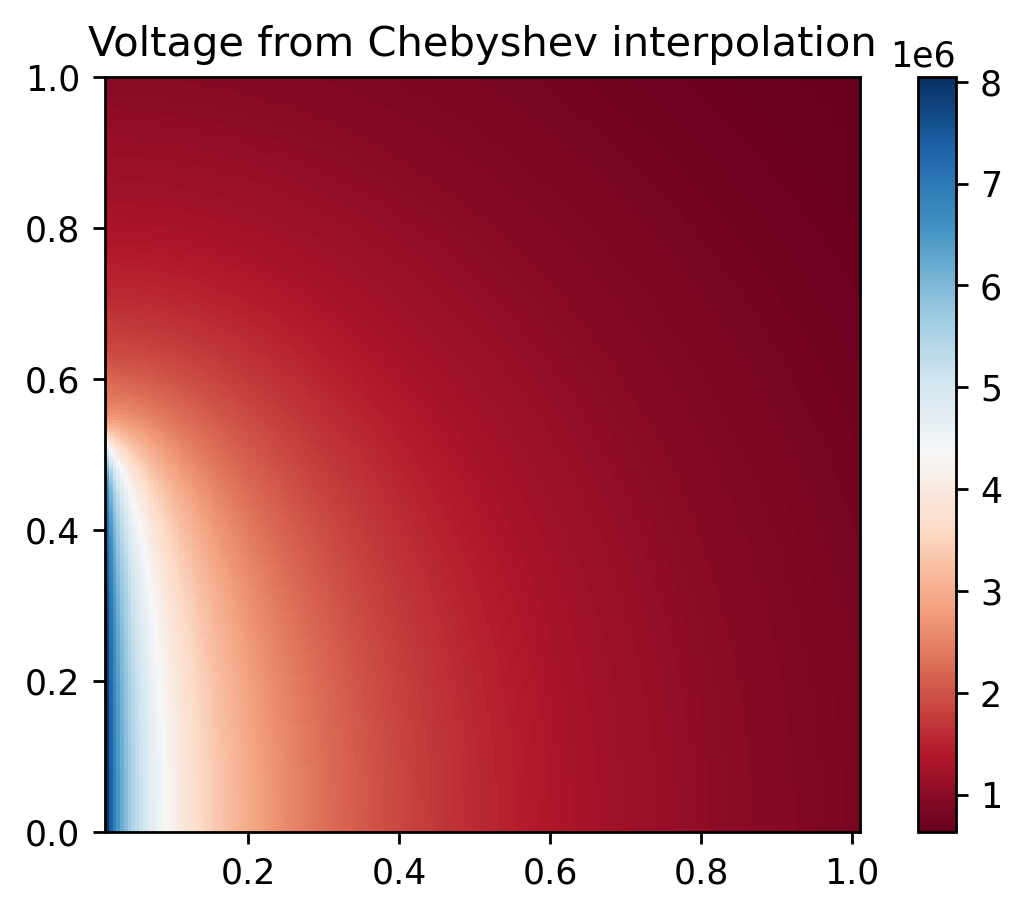

In [35]:
from numpy.polynomial.chebyshev import chebval2d
startTime=timeit.default_timer()
xc = (np.linspace(0.011,1.011,200)-0.011)*2-1  #map 0.011-1.011 onto -1 to 1
yc = (np.linspace(0.0,1.0,240)*2-1)  #map 0-1 oto -1 to 1
Xc,Yc = np.meshgrid(xc, yc) # grid of point
Zc = chebval2d(Xc,Yc,c) # evaluation of the function on the grid

elapsedTime=timeit.default_timer()-startTime
print('Elapsed time was ',elapsedTime)
im = plt.imshow(Zc,cmap=plt.cm.RdBu,extent=[0.01,1.01,0.0,1], origin='lower') # drawing the function
plt.colorbar(im) # adding the colobar on the right
plt.title('Voltage from Chebyshev interpolation')
plt.show()


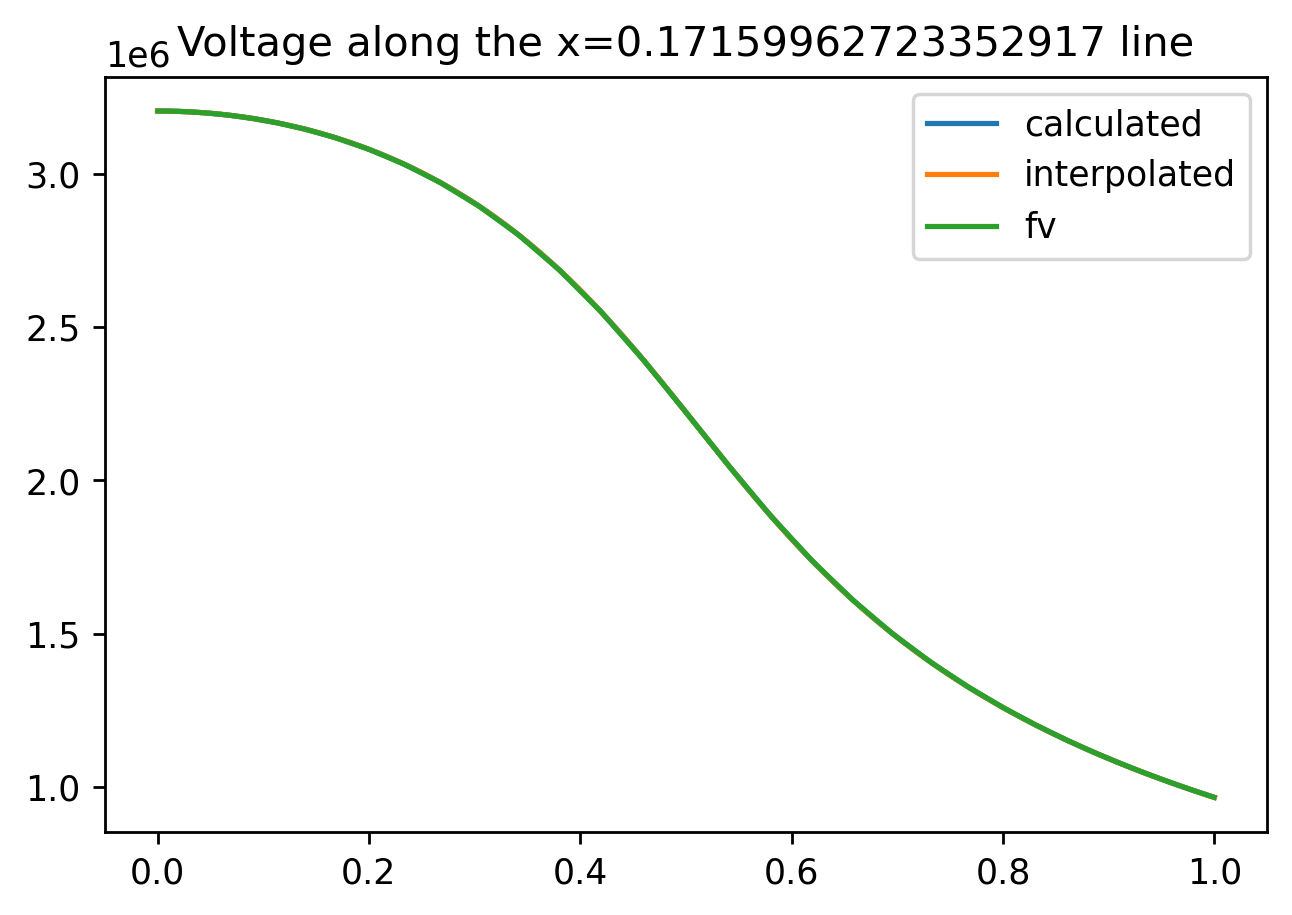

In [39]:
izero=10
xx=(xvalues[izero]+1)*0.5+0.011
z=np.linspace(0.0,1.0,200)
#cy2=np.array(chebinterpolate(vCheby,Ny-1,args=(xvalues[izero],)))
vinterp=np.array([chebval2d(xvalues[izero],2*zz-1,c) for zz in z])
#vinterp2=np.array(chebval(2*z-1,cy2))
v=np.array([voltage(xx,zz) for zz in z])
plt.title(f"Voltage along the x={xx} line")
plt.plot(z,v,label='calculated')
plt.plot(z,vinterp,label='interpolated')
#plt.plot(z,vinterp2,label='1d interpolation')
plt.plot(yvalues*0.5+0.5,fv[10,:],label='fv')
plt.legend()
plt.show()

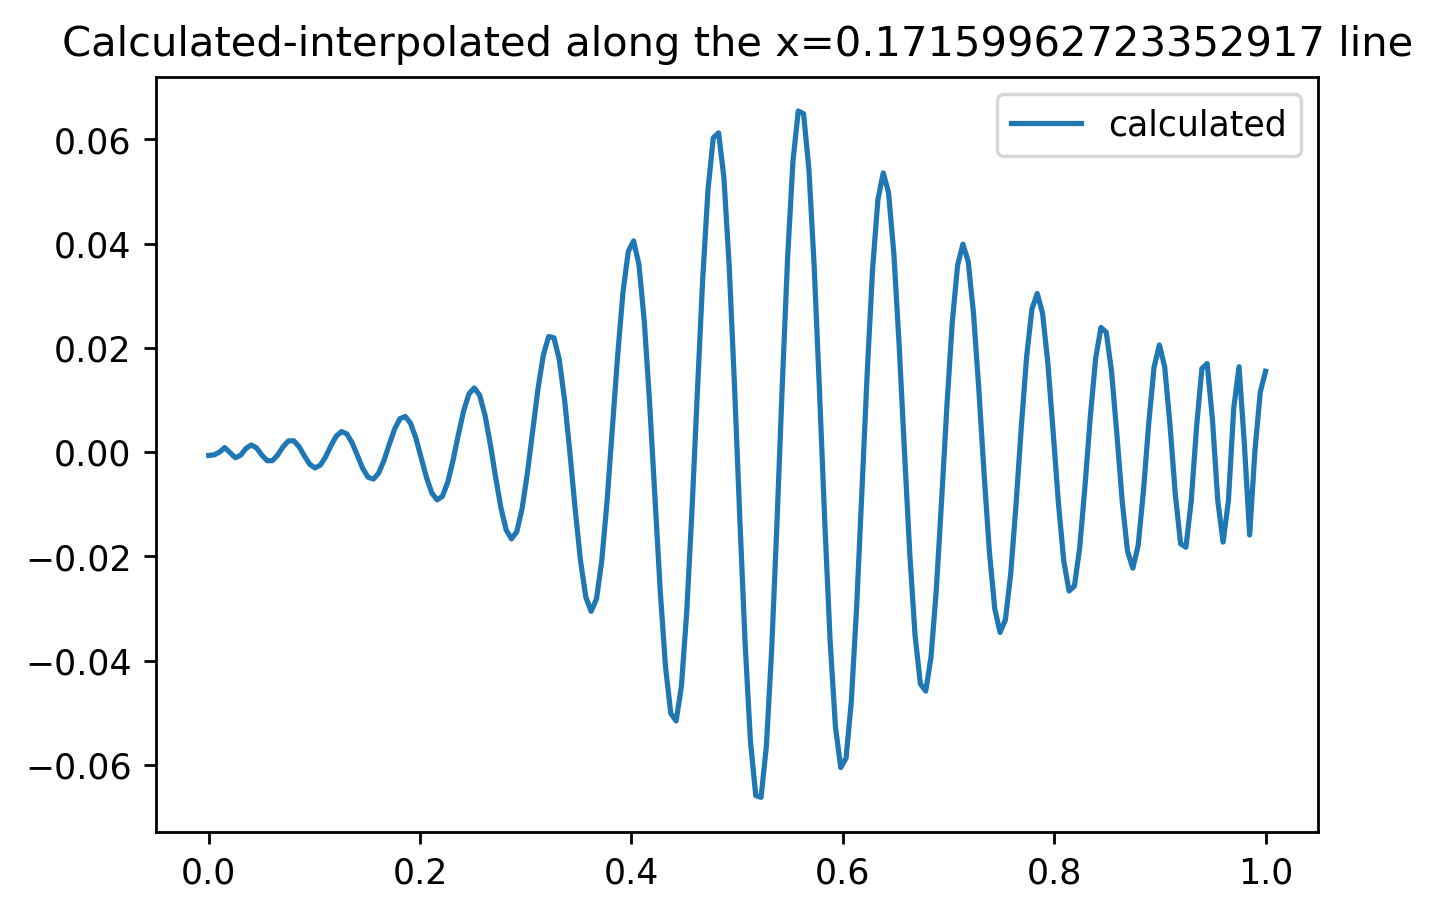

In [40]:
izero=10
xx=(xvalues[izero]+1)*0.5+0.011
#cy2=np.array(chebinterpolate(vCheby,Ny-1,args=(xvalues[izero],)))
vinterp=np.array([chebval2d((xx-0.011)*2-1,2*zz-1,c) for zz in z])
#vinterp2=np.array(chebval(2*z-1,cy2))
v=np.array([voltage(xx,zz) for zz in z])
plt.title(f"Calculated-interpolated along the x={xx} line")
plt.plot(z,v-vinterp,label='calculated')
plt.legend()
plt.show()

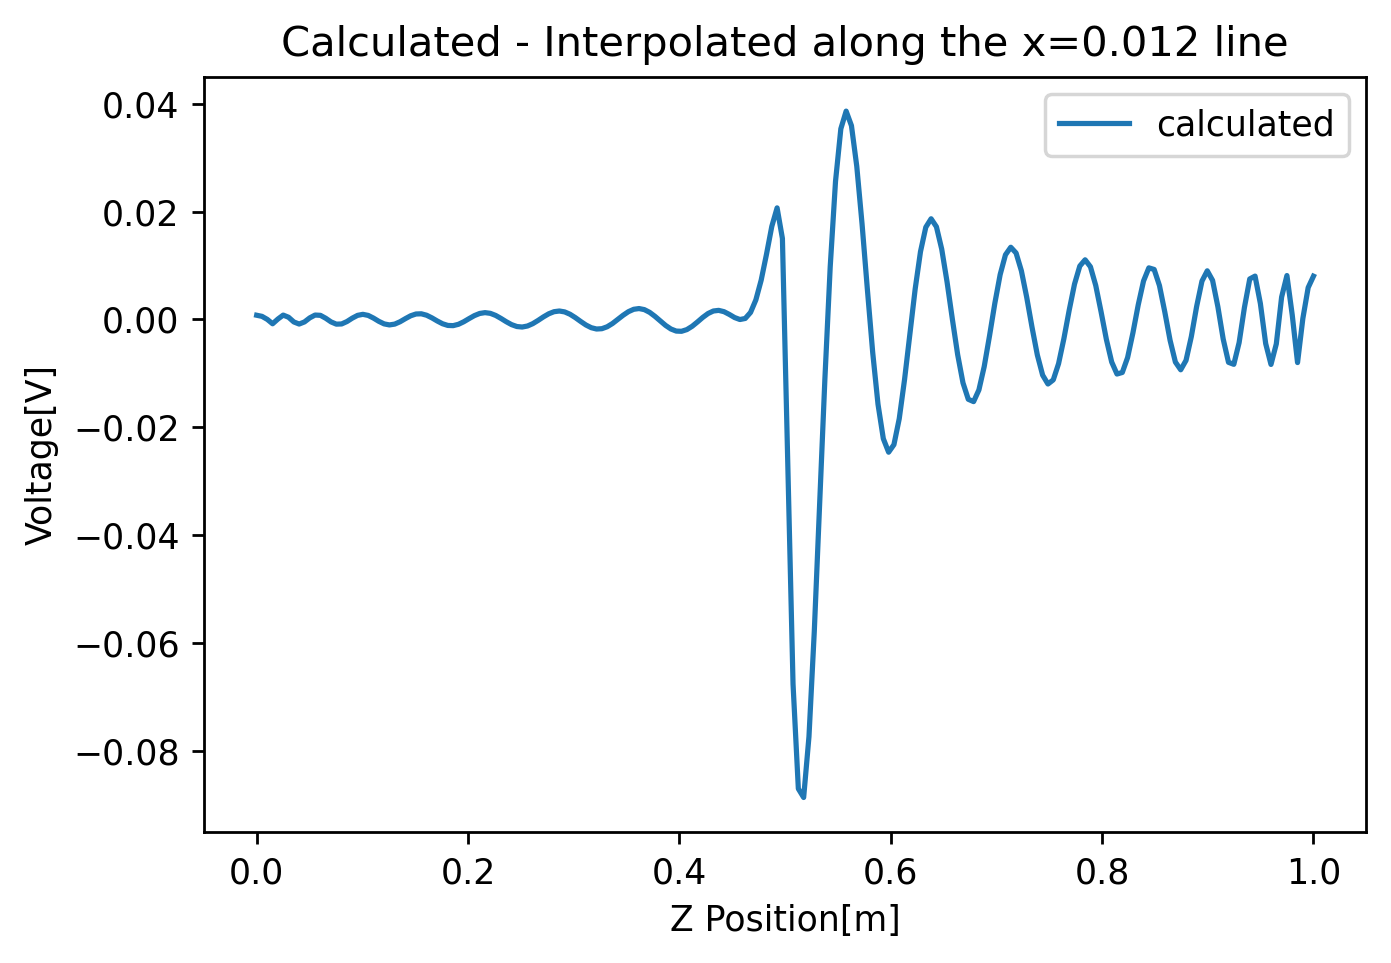

In [41]:
xx=0.012
vinterp=np.array([chebval2d((xx-0.011)*2-1,2*zz-1,c) for zz in z])
v=np.array([voltage(xx,zz) for zz in z])
plt.title(f"Calculated - Interpolated along the x={xx} line")
plt.plot(z,(v-vinterp)/v,label='calculated')
plt.xlabel('Z Position[m]')
plt.ylabel('Voltage[V]')
plt.legend()
plt.show()